# Brazilian E-Commerce Public Dataset by Olist

## Jacques CALLEWAERT M2IA

# Analyse exploratoire du e-commerce brésilien Olist

### Quels facteurs caractérisent les ventes, les clients et la qualité de service de la marketplace Olist ?



Presentation des fichiers : 

olist_customers_dataset.csv

olist_geolocation_dataset.csv

olist_order_items_dataset.csv

olist_order_payments_dataset.csv

olist_order_reviews_dataset.csv

olist_orders_dataset.csv

olist_products_dataset.csv

olist_sellers_dataset.csv

product_category_name_translation.csv

| Table       | Grain de la table                       | Identifiant important           |
| ----------- | --------------------------------------- | ------------------------------- |
| customers   | 1 ligne par `customer_id`               | `customer_id`                   |
| orders      | 1 ligne par commande                    | `order_id`                      |
| order_items | 1 ligne par article d'une commande      | `order_id + order_item_id`      |
| payments    | 1 ligne par opération de paiement       | `order_id + payment_sequential` |
| reviews     | 1 ligne par avis commande               | `review_id`, `order_id`         |
| products    | 1 ligne par produit                     | `product_id`                    |
| sellers     | 1 ligne par vendeur                     | `seller_id`                     |
| geolocation | plusieurs coordonnées possibles par ZIP | `geolocation_zip_code_prefix`   |
| translation | 1 catégorie portugaise → traduction     | `product_category_name`         |


#### Chargement des donnees et import

In [118]:
import geopandas as gpd
import pandas as pd
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
items = pd.read_csv("data/olist_order_items_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
translation = pd.read_csv("data/product_category_name_translation.csv")

#### Création d'une fonction pour inspecter les donnees

In [3]:
def inspect_dataframe(name, df):
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    print("Dimensions :", df.shape)
    print("\nTypes :")
    print(df.dtypes)
    print("\nValeurs manquantes :")
    print(df.isna().sum().sort_values(ascending=False))
    print("\nDoublons complets :", df.duplicated().sum())

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "translation": translation
}

for name, df in datasets.items():
    inspect_dataframe(name, df)

CUSTOMERS
Dimensions : (99441, 5)

Types :
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Valeurs manquantes :
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Doublons complets : 0
ORDERS
Dimensions : (99441, 8)

Types :
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Valeurs manquantes :
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
ord

#### Verification des cles primaires

In [5]:
print(
    "Doublons customer_id :",
    customers.duplicated(subset=["customer_id"]).sum()
)

print(
    "Doublons order_id :",
    orders.duplicated(subset=["order_id"]).sum()
)

print(
    "Doublons product_id :",
    products.duplicated(subset=["product_id"]).sum()
)

print(
    "Doublons seller_id :",
    sellers.duplicated(subset=["seller_id"]).sum()
)

Doublons customer_id : 0
Doublons order_id : 0
Doublons product_id : 0
Doublons seller_id : 0


In [6]:
items.duplicated(
    subset=["order_id", "order_item_id"]
).sum()

np.int64(0)

J'utilise deux colonnes parce que une commande peut avoir plusieurs articles

#### Verification des cles etrangeres (integrité referencielle )

In [7]:
# commandes sans client
orders.loc[
    ~orders["customer_id"].isin(customers["customer_id"])
].shape

(0, 8)

In [8]:
# articles sans commande
items.loc[
    ~items["order_id"].isin(orders["order_id"])
].shape

(0, 7)

In [9]:
# produits sans article
items.loc[
    ~items["product_id"].isin(products["product_id"])
].shape

(0, 7)

In [10]:
# articles sans vendeur
items.loc[
    ~items["seller_id"].isin(sellers["seller_id"])
].shape

(0, 7)

#### Valeurs manquantes

In [11]:
def missing_values(df):
    result = pd.DataFrame({
        "Nombre": df.isna().sum(),
        "Pourcentage": df.isna().mean() * 100
    })

    return result[result["Nombre"] > 0].sort_values(
        "Pourcentage",
        ascending=False
    )

missing_values(orders)

,Nombre,Pourcentage
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


Ici on peut avoir des commandes annulee, invalide ou encore deja expediee

In [12]:
missing_values(products)

,Nombre,Pourcentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [13]:
missing_values(reviews)

,Nombre,Pourcentage
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532


#### Conversion des dates

In [14]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [15]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

#### Creation de variables utiles

In [16]:
# temps de livraison 
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [17]:
# retard par rapport a la date prevue
orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [18]:
# livraison en retard
orders["is_late"] = orders["delay_days"] > 0

In [19]:
# mois d'achat
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

#### Pourquoi LEFT JOIN est important ici ? 
on utilise LEFT JOIN parce que la table de reference 'orders', et on veux garder toutes les commandes meme si certains infos de la table sont absentes

In [20]:
# exemple
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [21]:
# suppression si pas de correspondance
### how="inner"

#### Technique validate (cardinalité/jointure)

In [22]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

#### Agregation avant jointure

In [23]:
payments_order = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_transactions=("payment_sequential", "count"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

#### Paiements par commande

In [24]:
payments_order = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_transactions=("payment_sequential", "count"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

#### Articles par commande

In [25]:
items_order = (
    items
    .groupby("order_id")
    .agg(
        items_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        products_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

In [26]:
items_order["items_total"] = (
    items_order["products_value"]
    + items_order["freight_value"]
)

#### Avis par commande

In [27]:
reviews_order = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
    .reset_index()
)

#### Créer la table analytique principale

In [28]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

In [29]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

In [30]:
print("Nombre de commandes :", orders["order_id"].nunique())
print("Nombre de lignes après jointures :", len(df))

Nombre de commandes : 99441
Nombre de lignes après jointures : 99441


On a bien 1 ligne = 1 commande

In [31]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days', 'is_late', 'purchase_month', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [32]:
[col for col in df.columns if "payment" in col.lower()]

[]

In [33]:
payments_order = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_transactions=("payment_sequential", "count"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

payments_order.head()

,order_id,payment_value,payment_transactions,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3


In [34]:
print(payments_order.columns)

Index(['order_id', 'payment_value', 'payment_transactions',
       'max_installments'],
      dtype='str')


In [35]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

df = df.merge(
    payments_order,
    on="order_id",
    how="left",
    validate="one_to_one"
)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,is_late,purchase_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_transactions,max_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,False,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,False,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,False,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.0,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,False,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,False,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,1.0


In [37]:
print(df.shape)
print(df.columns.tolist())

(99441, 19)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days', 'is_late', 'purchase_month', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_value', 'payment_transactions', 'max_installments']


In [38]:
print("payment_value" in df.columns)

True


In [39]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [41]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [42]:
orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [43]:
orders["is_late"] = orders["delay_days"] > 0

In [44]:
items_order = (
    items
    .groupby("order_id")
    .agg(
        items_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        products_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

items_order["items_total"] = (
    items_order["products_value"]
    + items_order["freight_value"]
)

items_order.head()

,order_id,items_count,unique_products,unique_sellers,products_value,freight_value,items_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,218.04


In [45]:
reviews_order = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
    .reset_index()
)

reviews_order.head()

,order_id,review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [46]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

df = df.merge(
    payments_order,
    on="order_id",
    how="left",
    validate="one_to_one"
)

df = df.merge(
    items_order,
    on="order_id",
    how="left",
    validate="one_to_one"
)

df = df.merge(
    reviews_order,
    on="order_id",
    how="left",
    validate="one_to_one"
)

print("Dimensions finales :", df.shape)

df.head()

Dimensions finales : (99441, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,is_late,purchase_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_transactions,max_installments,items_count,unique_products,unique_sellers,products_value,freight_value,items_total,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,False,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.0,1.0,1.0,1.0,1.0,29.99,8.72,38.71,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,False,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0,1.0,1.0,1.0,118.70,22.76,141.46,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,False,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.0,3.0,1.0,1.0,1.0,159.90,19.22,179.12,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,False,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,1.0,1.0,1.0,1.0,45.00,27.20,72.20,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,False,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,1.0,1.0,1.0,1.0,19.90,8.72,28.62,5.0,1.0


In [47]:
print("Nombre de lignes :", len(df))
print("Nombre de commandes uniques :", df["order_id"].nunique())

Nombre de lignes : 99441
Nombre de commandes uniques : 99441


#### Les KPI à calculer

In [49]:
nb_orders = df["order_id"].nunique()

nb_customers = df["customer_unique_id"].nunique()

total_paid = df["payment_value"].sum()

average_order = df["payment_value"].mean()

median_order = df["payment_value"].median()

average_review = df["review_score"].mean()

average_delivery = df["delivery_days"].mean()

late_rate = df["is_late"].mean() * 100

print("Nombre de commandes :", nb_orders)
print("Nombre de clients :", nb_customers)
print("Montant total payé :", round(total_paid, 2))
print("Panier moyen :", round(average_order, 2))
print("Panier médian :", round(median_order, 2))
print("Note moyenne :", round(average_review, 2))
print("Livraison moyenne :", round(average_delivery, 2))
print("Taux de retard :", round(late_rate, 2), "%")

Nombre de commandes : 99441
Nombre de clients : 96096
Montant total payé : 16008872.12
Panier moyen : 160.99
Panier médian : 105.29
Note moyenne : 4.09
Livraison moyenne : 12.56
Taux de retard : 7.87 %


#### Moyenne VS médiane

Panier moyen : 160
Panier médian : 100

La moyenne est supérieure à la médiane, ce qui montre une distribution asymétrique vers les grandes valeurs. Certaines commandes très élevées tirent la moyenne vers le haut.

#### Detection des valeurs aberrantes avec l'IQR (IQR=Q3−Q1)

In [50]:
def detect_outliers_iqr(series):
    series = series.dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[
        (series < lower) |
        (series > upper)
    ]

    return q1, q3, iqr, lower, upper, outliers

In [51]:
q1, q3, iqr, lower, upper, outliers = detect_outliers_iqr(
    df["payment_value"]
)

print("Q1 :", q1)
print("Q3 :", q3)
print("IQR :", iqr)
print("Borne basse :", lower)
print("Borne haute :", upper)
print("Nombre d'outliers :", len(outliers))

Q1 : 62.01
Q3 : 176.97
IQR : 114.96000000000001
Borne basse : -110.43
Borne haute : 349.40999999999997
Nombre d'outliers : 7866


#### La boite a moustaches (graphique specialisé pour reconaire les Valeurs aberantes)

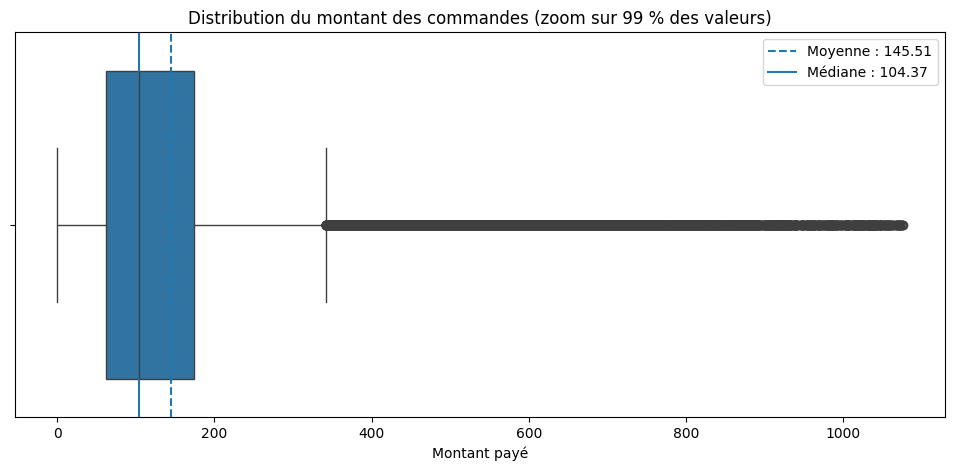

99e percentile : 1075.79
Nombre de valeurs au-dessus du 99e percentile : 995


In [53]:
# On calcule une borne haute d'affichage (99e percentile)
q99 = df["payment_value"].quantile(0.99)

# Données utilisées uniquement pour l'affichage
payment_zoom = df[df["payment_value"] <= q99]["payment_value"]

# Statistiques utiles
mean_val = payment_zoom.mean()
median_val = payment_zoom.median()

plt.figure(figsize=(12, 5))

sns.boxplot(x=payment_zoom)

plt.axvline(mean_val, linestyle="--", label=f"Moyenne : {mean_val:.2f}")
plt.axvline(median_val, linestyle="-", label=f"Médiane : {median_val:.2f}")

plt.title("Distribution du montant des commandes (zoom sur 99 % des valeurs)")
plt.xlabel("Montant payé")
plt.legend()
plt.show()

print("99e percentile :", round(q99, 2))
print("Nombre de valeurs au-dessus du 99e percentile :", (df["payment_value"] > q99).sum())

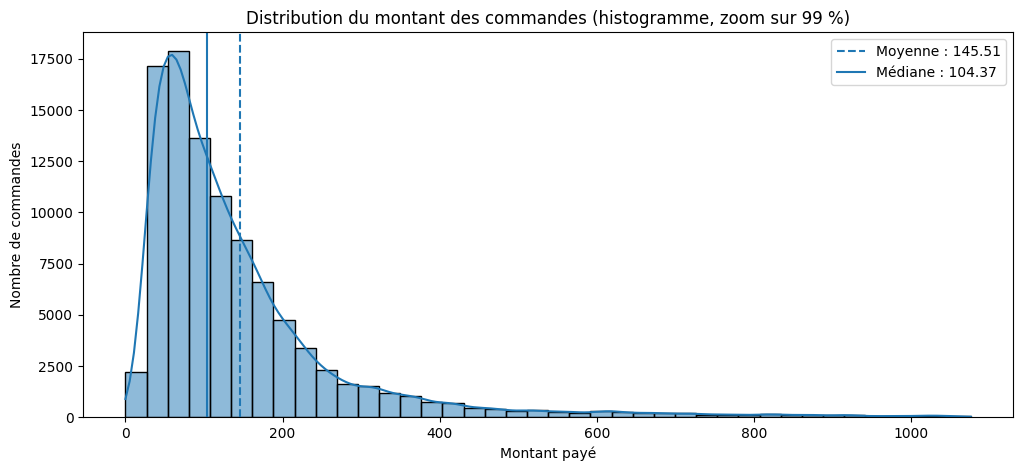

In [54]:
q99 = df["payment_value"].quantile(0.99)
payment_zoom = df[df["payment_value"] <= q99]["payment_value"]

mean_val = payment_zoom.mean()
median_val = payment_zoom.median()

plt.figure(figsize=(12, 5))

sns.histplot(payment_zoom, bins=40, kde=True)

plt.axvline(mean_val, linestyle="--", label=f"Moyenne : {mean_val:.2f}")
plt.axvline(median_val, linestyle="-", label=f"Médiane : {median_val:.2f}")

plt.title("Distribution du montant des commandes (histogramme, zoom sur 99 %)")
plt.xlabel("Montant payé")
plt.ylabel("Nombre de commandes")
plt.legend()
plt.show()

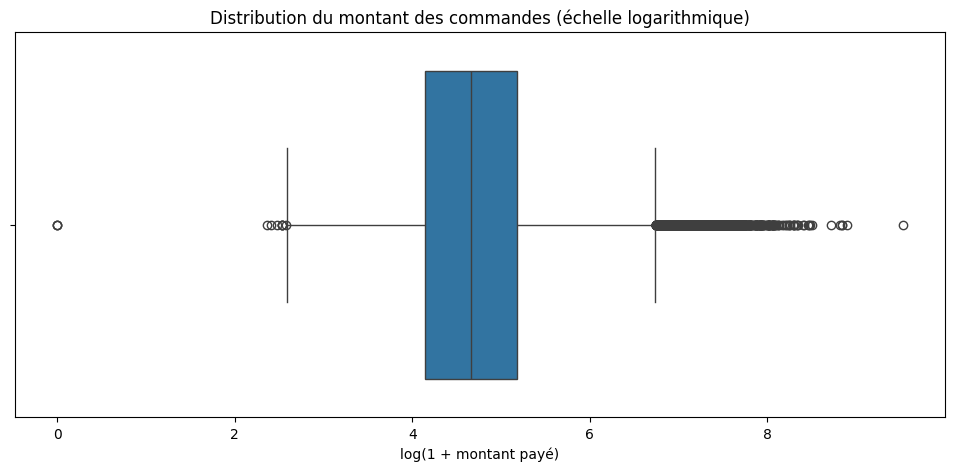

In [55]:
plt.figure(figsize=(12, 5))

sns.boxplot(x=np.log1p(df["payment_value"]))

plt.title("Distribution du montant des commandes (échelle logarithmique)")
plt.xlabel("log(1 + montant payé)")
plt.show()

Une valeur aberrante statistiquement n'est pas forcément une erreur. Une commande très chère peut être parfaitement réelle. Je vérifie donc son contexte avant de décider de l'exclure.

#### Statistiques descriptives

In [57]:
df[
    [
        "payment_value",
        "delivery_days",
        "review_score",
        "products_value",
        "freight_value"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
payment_value,99440.0,160.990267,221.951257,0.000000,62.010000,105.290000,176.970000,13664.080000
delivery_days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
review_score,98673.0,4.086793,1.346274,1.000000,4.000000,5.000000,5.000000,5.000000
products_value,98666.0,137.754076,210.645145,0.850000,45.900000,86.900000,149.900000,13440.000000
freight_value,98666.0,22.823562,21.650909,0.000000,13.850000,17.170000,24.040000,1794.960000


In [58]:
stats = df[
    [
        "payment_value",
        "delivery_days",
        "products_value",
        "freight_value"
    ]
].describe().T

stats["IQR"] = (
    stats["75%"]
    - stats["25%"]
)

stats

,count,mean,std,min,25%,50%,75%,max,IQR
payment_value,99440.0,160.990267,221.951257,0.000000,62.010000,105.290000,176.970000,13664.080000,114.960000
delivery_days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611,8.953924
products_value,98666.0,137.754076,210.645145,0.850000,45.900000,86.900000,149.900000,13440.000000,104.000000
freight_value,98666.0,22.823562,21.650909,0.000000,13.850000,17.170000,24.040000,1794.960000,10.190000


#### Graphique statut des commandes 

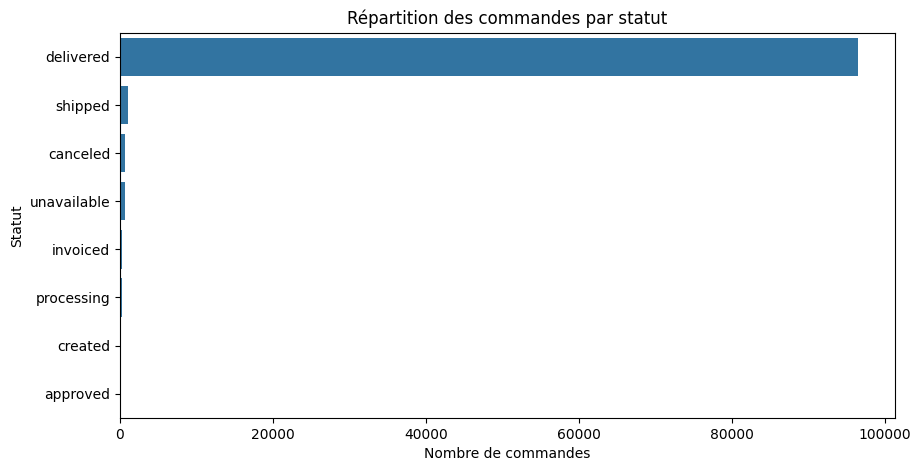

In [59]:
status_counts = (
    orders["order_status"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=status_counts.values,
    y=status_counts.index
)

plt.title("Répartition des commandes par statut")
plt.xlabel("Nombre de commandes")
plt.ylabel("Statut")

plt.show()

Le graphique actuel est correct, mais il est peu représentatif visuellement parce que la catégorie delivered écrase toutes les autres

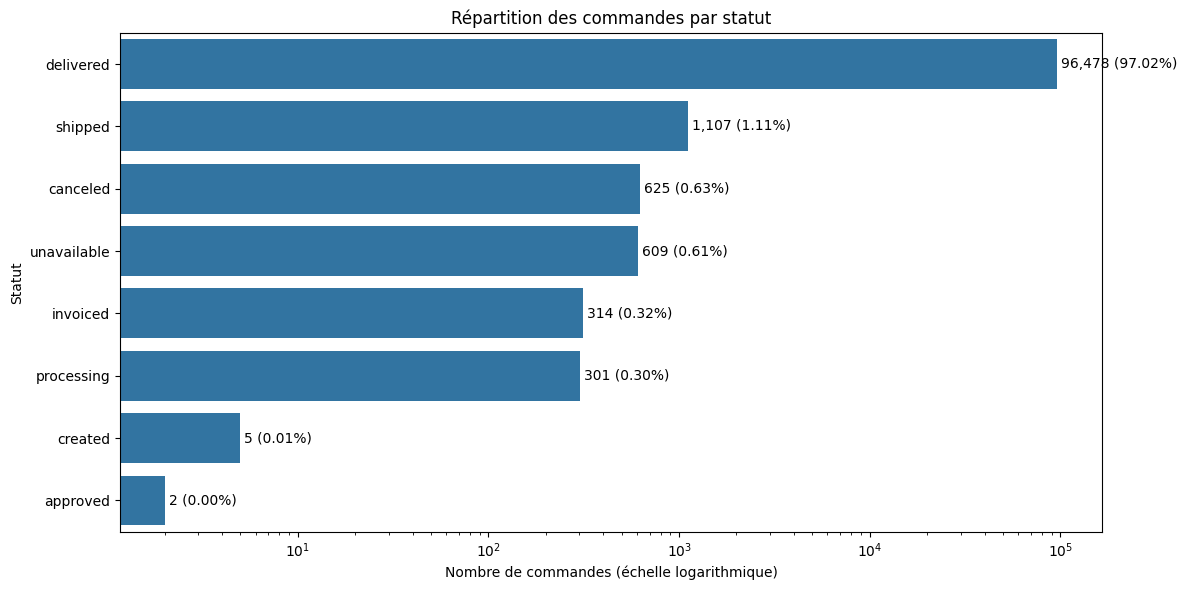

In [ ]:
# Comptage des statuts
status_counts = orders["order_status"].value_counts()

# DataFrame propre
status_df = status_counts.reset_index()
status_df.columns = ["order_status", "count"]

# Pourcentage
status_df["percent"] = status_df["count"] / status_df["count"].sum() * 100

# Graphique
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=status_df,
    x="count",
    y="order_status"
)

# Échelle logarithmique pour mieux voir les petites catégories
ax.set_xscale("log")

# Ajouter les annotations
for i, row in status_df.iterrows():
    ax.text(
        row["count"] * 1.05,
        i,
        f"{row['count']:,} ({row['percent']:.2f}%)",
        va="center"
    )

plt.title("Répartition des commandes par statut")
plt.xlabel("Nombre de commandes (échelle logarithmique)")
plt.ylabel("Statut")
plt.tight_layout()
plt.show()

On a le meme graphe sauf que le deuxièeme est mis a l'echelle avec un log

#### Graphique Évolution mensuelle des ventes

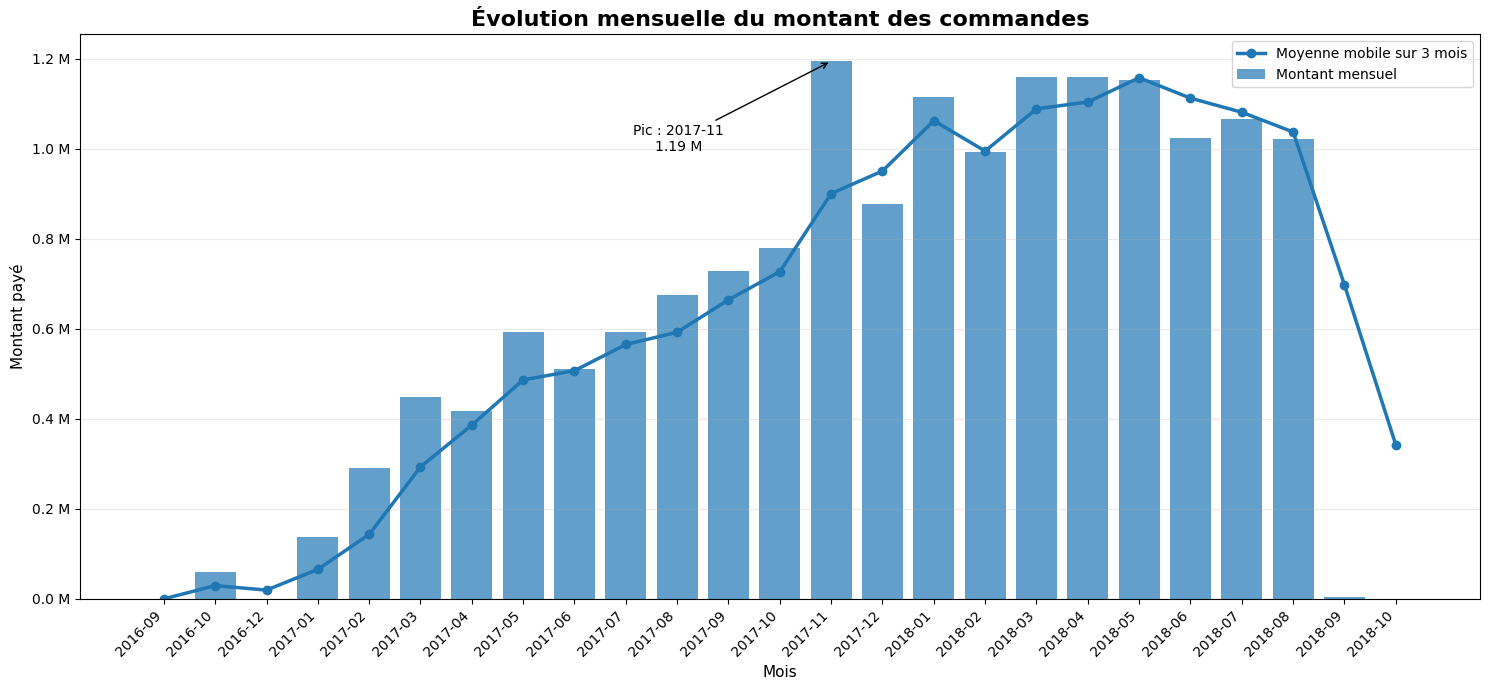

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# =========================
# 1. Agrégation mensuelle
# =========================
monthly_sales = (
    df.groupby("purchase_month")
      .agg(
          montant_total=("payment_value", "sum"),
          nb_commandes=("order_id", "nunique")
      )
      .reset_index()
      .sort_values("purchase_month")
)

# Moyenne mobile sur 3 mois
monthly_sales["moyenne_mobile_3m"] = (
    monthly_sales["montant_total"]
    .rolling(window=3, min_periods=1)
    .mean()
)

# =========================
# 2. Graphique
# =========================
fig, ax = plt.subplots(figsize=(15, 7))

# Barres = montant réellement observé chaque mois
ax.bar(
    monthly_sales["purchase_month"],
    monthly_sales["montant_total"],
    alpha=0.7,
    label="Montant mensuel"
)

# Courbe = tendance lissée sur 3 mois
ax.plot(
    monthly_sales["purchase_month"],
    monthly_sales["moyenne_mobile_3m"],
    marker="o",
    linewidth=2.5,
    label="Moyenne mobile sur 3 mois"
)

# =========================
# 3. Mise en forme
# =========================
ax.set_title(
    "Évolution mensuelle du montant des commandes",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Mois", fontsize=11)
ax.set_ylabel("Montant payé", fontsize=11)

# Afficher l'axe Y en millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} M")
)

plt.xticks(rotation=45, ha="right")

ax.grid(axis="y", alpha=0.25)

ax.legend()

# =========================
# 4. Annoter le meilleur mois
# =========================
max_idx = monthly_sales["montant_total"].idxmax()

max_month = monthly_sales.loc[max_idx, "purchase_month"]
max_value = monthly_sales.loc[max_idx, "montant_total"]

ax.annotate(
    f"Pic : {max_month}\n{max_value/1_000_000:.2f} M",
    xy=(monthly_sales.index.get_loc(max_idx), max_value),
    xytext=(-110,- 65),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

Le diagramme en barres est plus adapté parce qu’un mois représente une période distincte : on compare donc facilement le montant généré mois par mois. La moyenne mobile sur trois mois ajoute une information différente : elle réduit les fluctuations ponctuelles et permet de voir la tendance générale.

In [78]:
monthly_sales[
    ["purchase_month", "nb_commandes", "montant_total"]
].tail(6)

,purchase_month,nb_commandes,montant_total
19,2018-05,6873,1153982.15
20,2018-06,6167,1023880.50
21,2018-07,6292,1066540.75
22,2018-08,6512,1022425.32
23,2018-09,16,4439.54
24,2018-10,4,589.67


Les derniers mois ne sont pas comparables aux mois complets car le dataset ne contient qu’une partie de leur activité. Ils sont donc conservés pour la transparence, mais ne sont pas utilisés pour conclure à une baisse réelle des ventes.

#### Graphique Modes de paiment

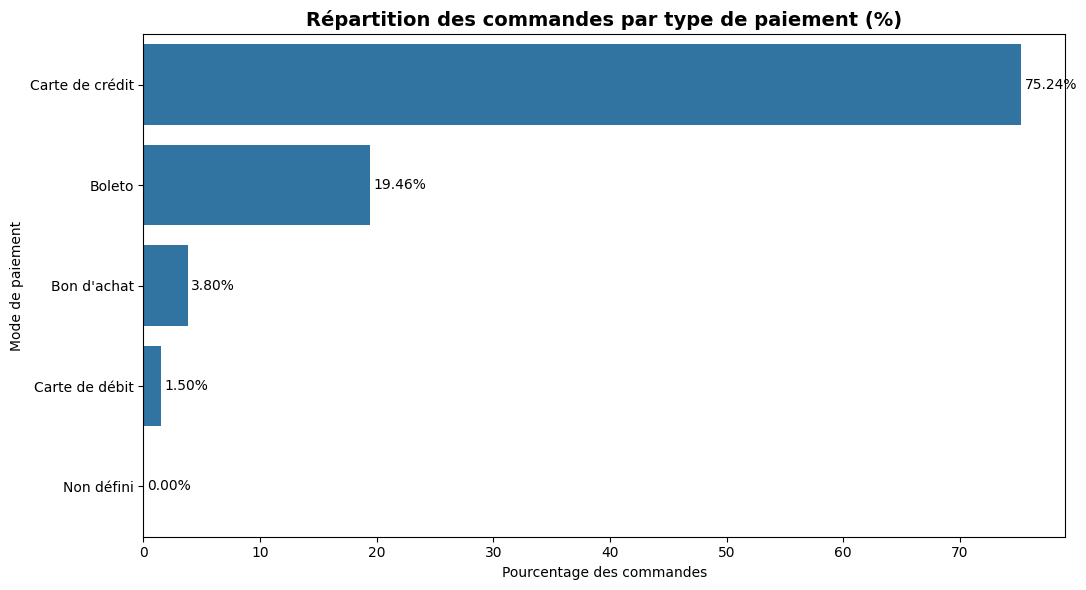

In [82]:
payment_percent = (
    payments
    .groupby("payment_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

payment_percent = (payment_percent / payment_percent.sum() * 100).reset_index()
payment_percent.columns = ["payment_type", "percent"]
payment_percent["payment_label"] = payment_percent["payment_type"].map(payment_labels)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=payment_percent,
    x="percent",
    y="payment_label"
)

for i, row in payment_percent.iterrows():
    ax.text(
        row["percent"] + 0.3,
        i,
        f"{row['percent']:.2f}%",
        va="center"
    )

plt.title("Répartition des commandes par type de paiement (%)", fontsize=14, fontweight="bold")
plt.xlabel("Pourcentage des commandes")
plt.ylabel("Mode de paiement")
plt.tight_layout()
plt.show()

Le diagramme en barres horizontales est adapté car payment_type est une variable qualitative nominale


#### Graphique États avec le plus de commandes

Geopandas

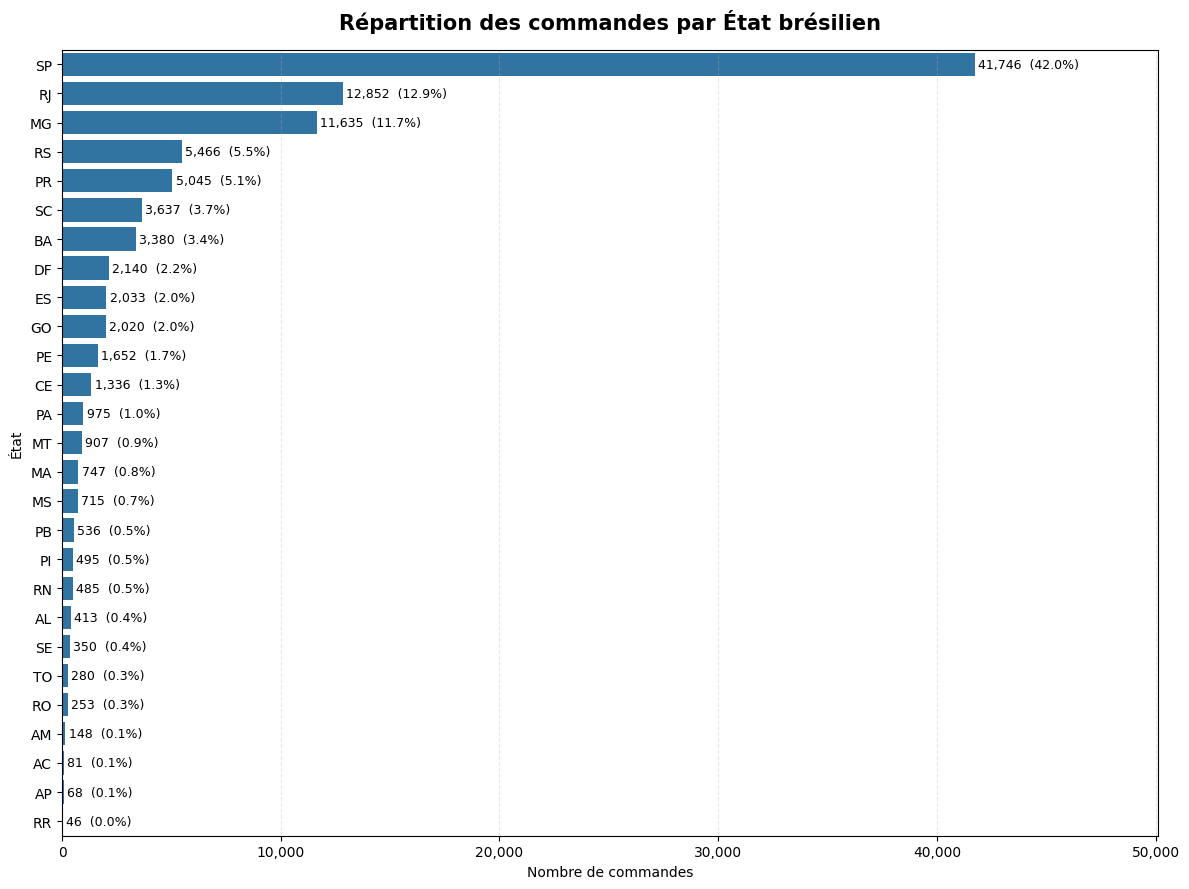

In [ ]:

# Nombre de commandes par État


state_orders = (
    df.groupby("customer_state")["order_id"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
)

state_orders.columns = ["Etat", "Nombre_commandes"]

# Pourcentage du total
state_orders["Pourcentage"] = (
    state_orders["Nombre_commandes"]
    / state_orders["Nombre_commandes"].sum()
    * 100
)

# Graphique


plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=state_orders,
    x="Nombre_commandes",
    y="Etat"
)


# Ajouter effectif + pourcentage


for i, row in state_orders.iterrows():

    ax.text(
        row["Nombre_commandes"] + 150,
        i,
        f'{row["Nombre_commandes"]:,}  ({row["Pourcentage"]:.1f}%)',
        va="center",
        fontsize=9
    )


#  Mise en forme


plt.title(
    "Répartition des commandes par État brésilien",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Nombre de commandes")
plt.ylabel("État")

# Format des milliers
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

# Grille légère
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)


plt.xlim(
    0,
    state_orders["Nombre_commandes"].max() * 1.20
)

plt.tight_layout()
plt.show()

customer_state est une variable qualitative nominale. Un diagramme en barres est donc approprié pour comparer les effectifs entre catégorie, le format horizontal est meilleur ici parce qu’il y a beaucoup d’États

In [102]:
state_orders = (
    df.groupby("customer_state")["order_id"]
      .nunique()
      .reset_index()
)

state_orders.columns = [
    "UF",
    "Nombre_commandes"
]

state_orders.head()

,UF,Nombre_commandes
0,AC,81
1,AL,413
2,AM,148
3,AP,68
4,BA,3380


In [103]:
url = (
    "https://raw.githubusercontent.com/"
    "giuliano-macedo/geodata-br-states/main/"
    "geojson/br_states.json"
)

brazil_states = gpd.read_file(url)

In [104]:
brazil_states.head()

,id,FID_Export,SIGLA,Total,Homens,Mulheres,Urbana,Rural,TX_Alfab,FID_estado,Estado,FK_macro,PK_sigla,geometry
0,AC,0,AC,557526,280983,276543,370267,187259,65.154545,-1,Acre,N,AC,"MULTIPOLYGON (((-66.80619 -9.81446, -66.64485 ..."
1,AL,1,AL,2822621,1378942,1443679,1919739,902882,59.364356,-1,Alagoas,NE,AL,"MULTIPOLYGON (((-35.15263 -8.91373, -35.15628 ..."
2,AM,2,AM,2812557,1414367,1398190,2107222,705335,72.250000,-1,Amazonas,N,AM,"MULTIPOLYGON (((-67.3259 2.02976, -67.30001 1...."
3,AP,3,AP,477032,239453,237579,424683,52349,83.650000,-1,Amapá,N,AP,"MULTIPOLYGON (((-50.09389 0.70205, -50.15695 0..."
4,BA,4,BA,13070250,6462033,6608217,8772348,4297902,71.163373,-1,Bahia,NE,BA,"MULTIPOLYGON (((-38.64899 -18.03612, -38.65822..."


In [105]:
print(brazil_states.columns)

Index(['id', 'FID_Export', 'SIGLA', 'Total', 'Homens', 'Mulheres', 'Urbana',
       'Rural', 'TX_Alfab', 'FID_estado', 'Estado', 'FK_macro', 'PK_sigla',
       'geometry'],
      dtype='str')


In [106]:
brazil_states.columns.tolist()

['id',
 'FID_Export',
 'SIGLA',
 'Total',
 'Homens',
 'Mulheres',
 'Urbana',
 'Rural',
 'TX_Alfab',
 'FID_estado',
 'Estado',
 'FK_macro',
 'PK_sigla',
 'geometry']

In [107]:
brazil_states.head()

,id,FID_Export,SIGLA,Total,Homens,Mulheres,Urbana,Rural,TX_Alfab,FID_estado,Estado,FK_macro,PK_sigla,geometry
0,AC,0,AC,557526,280983,276543,370267,187259,65.154545,-1,Acre,N,AC,"MULTIPOLYGON (((-66.80619 -9.81446, -66.64485 ..."
1,AL,1,AL,2822621,1378942,1443679,1919739,902882,59.364356,-1,Alagoas,NE,AL,"MULTIPOLYGON (((-35.15263 -8.91373, -35.15628 ..."
2,AM,2,AM,2812557,1414367,1398190,2107222,705335,72.250000,-1,Amazonas,N,AM,"MULTIPOLYGON (((-67.3259 2.02976, -67.30001 1...."
3,AP,3,AP,477032,239453,237579,424683,52349,83.650000,-1,Amapá,N,AP,"MULTIPOLYGON (((-50.09389 0.70205, -50.15695 0..."
4,BA,4,BA,13070250,6462033,6608217,8772348,4297902,71.163373,-1,Bahia,NE,BA,"MULTIPOLYGON (((-38.64899 -18.03612, -38.65822..."


In [109]:
state_to_uf = {
    "Acre": "AC",
    "Alagoas": "AL",
    "Amapá": "AP",
    "Amazonas": "AM",
    "Bahia": "BA",
    "Ceará": "CE",
    "Distrito Federal": "DF",
    "Espírito Santo": "ES",
    "Goiás": "GO",
    "Maranhão": "MA",
    "Mato Grosso": "MT",
    "Mato Grosso do Sul": "MS",
    "Minas Gerais": "MG",
    "Pará": "PA",
    "Paraíba": "PB",
    "Paraná": "PR",
    "Pernambuco": "PE",
    "Piauí": "PI",
    "Rio de Janeiro": "RJ",
    "Rio Grande do Norte": "RN",
    "Rio Grande do Sul": "RS",
    "Rondônia": "RO",
    "Roraima": "RR",
    "Santa Catarina": "SC",
    "São Paulo": "SP",
    "Sergipe": "SE",
    "Tocantins": "TO"
}

In [110]:
brazil_states.head()

,id,FID_Export,SIGLA,Total,Homens,Mulheres,Urbana,Rural,TX_Alfab,FID_estado,Estado,FK_macro,PK_sigla,geometry
0,AC,0,AC,557526,280983,276543,370267,187259,65.154545,-1,Acre,N,AC,"MULTIPOLYGON (((-66.80619 -9.81446, -66.64485 ..."
1,AL,1,AL,2822621,1378942,1443679,1919739,902882,59.364356,-1,Alagoas,NE,AL,"MULTIPOLYGON (((-35.15263 -8.91373, -35.15628 ..."
2,AM,2,AM,2812557,1414367,1398190,2107222,705335,72.250000,-1,Amazonas,N,AM,"MULTIPOLYGON (((-67.3259 2.02976, -67.30001 1...."
3,AP,3,AP,477032,239453,237579,424683,52349,83.650000,-1,Amapá,N,AP,"MULTIPOLYGON (((-50.09389 0.70205, -50.15695 0..."
4,BA,4,BA,13070250,6462033,6608217,8772348,4297902,71.163373,-1,Bahia,NE,BA,"MULTIPOLYGON (((-38.64899 -18.03612, -38.65822..."


In [111]:
brazil_states["UF"] = brazil_states["Estado"].map(state_to_uf)

In [112]:
map_data = brazil_states.merge(
    state_orders,
    on="UF",
    how="left"
)

In [113]:
map_data[
    ["UF", "Nombre_commandes"]
].head()

,UF,Nombre_commandes
0,AC,81
1,AL,413
2,AM,148
3,AP,68
4,BA,3380


In [114]:
map_data[
    map_data["Nombre_commandes"].isna()
][["UF"]]

,UF


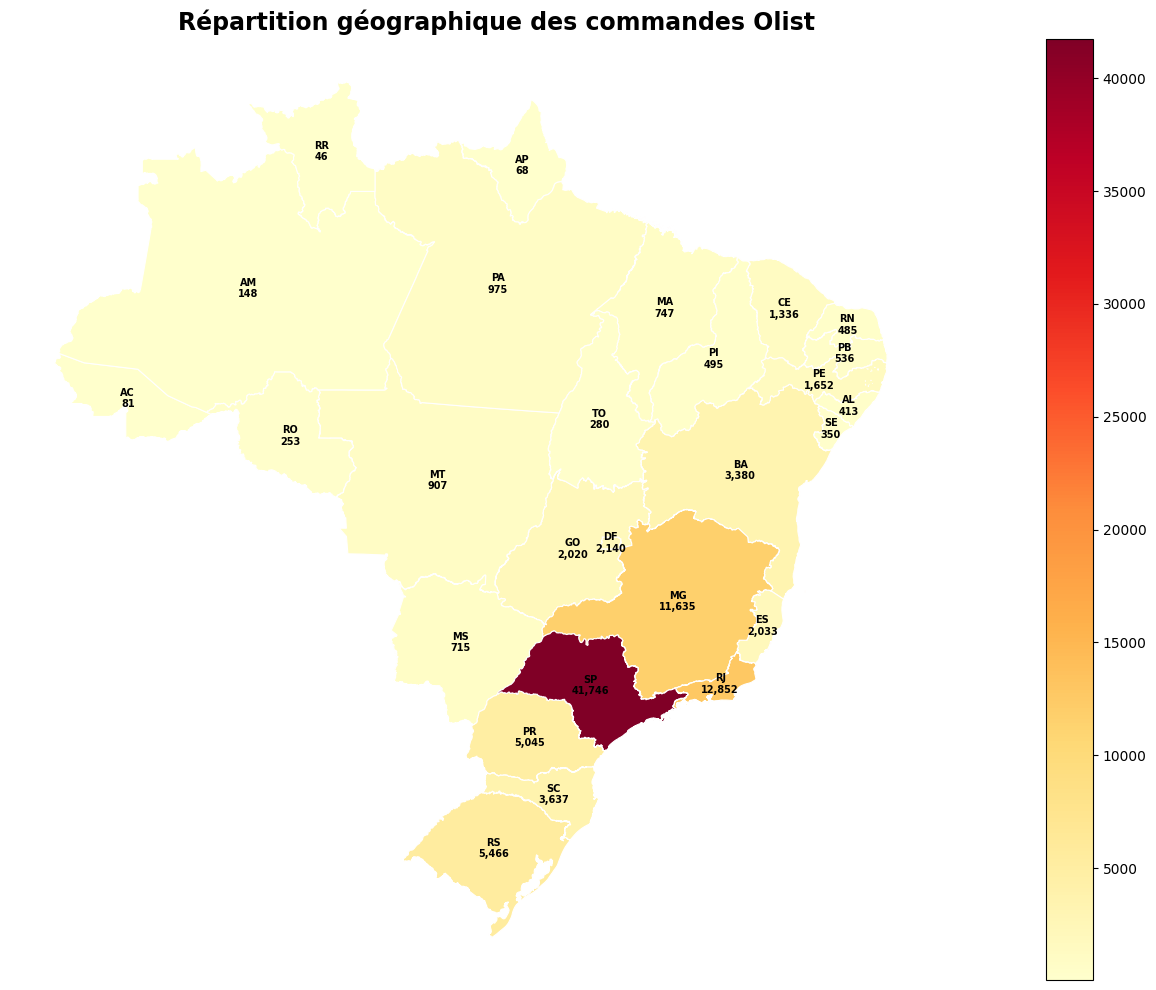

In [117]:
fig, ax = plt.subplots(figsize=(13, 10))

map_data.plot(
    column="Nombre_commandes",
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)

centroids = map_data.to_crs(epsg=31983).centroid

centroids = gpd.GeoSeries(
    centroids,
    crs="EPSG:31983"
).to_crs(map_data.crs)

for idx, row in map_data.iterrows():

    if pd.notna(row["Nombre_commandes"]):

        ax.annotate(
            text=f"{row['UF']}\n{int(row['Nombre_commandes']):,}",
            xy=(
                centroids.iloc[idx].x,
                centroids.iloc[idx].y
            ),
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold"
        )

ax.set_title(
    "Répartition géographique des commandes Olist",
    fontsize=17,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()

#### Construire la table produit

In [ ]:
# analyser les catégories
items_products = items.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

In [88]:
items_products = items_products.merge(
    translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

In [90]:
items_products["category"] = (
    items_products["product_category_name_english"]
    .fillna(items_products["product_category_name"])
    .fillna("unknown")
)

#### Graphique Top catégories

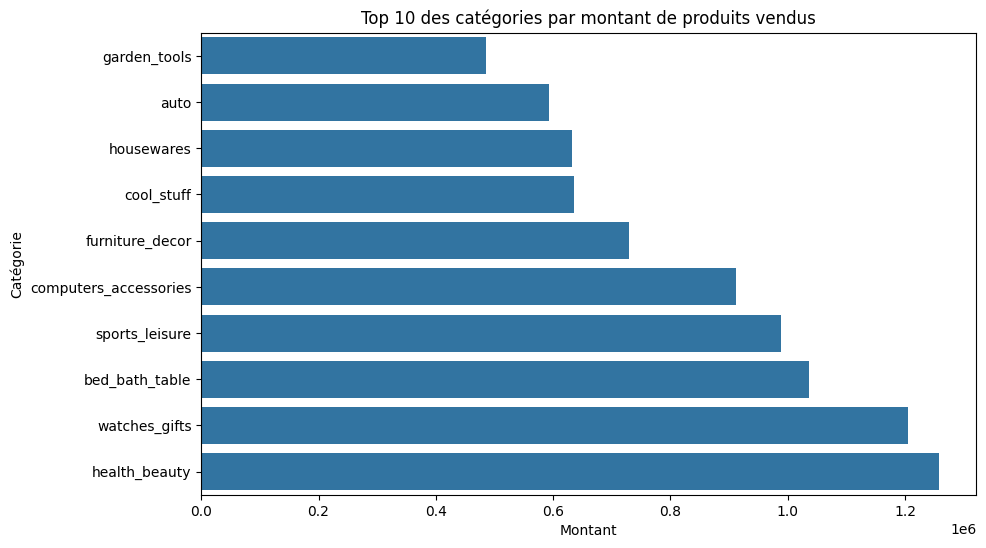

In [91]:
top_categories = (
    items_products
    .groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 des catégories par montant de produits vendus")
plt.xlabel("Montant")
plt.ylabel("Catégorie")

plt.show()

Analyse de price et non de payment_value parce que la categorie est liée aux articles et pas au operation de paiement

#### Graphique Distribution des delais de livraison

In [92]:
# delais cohérent
delivery = df[
    (df["order_status"] == "delivered") &
    (df["delivery_days"].notna()) &
    (df["delivery_days"] >= 0)
].copy()

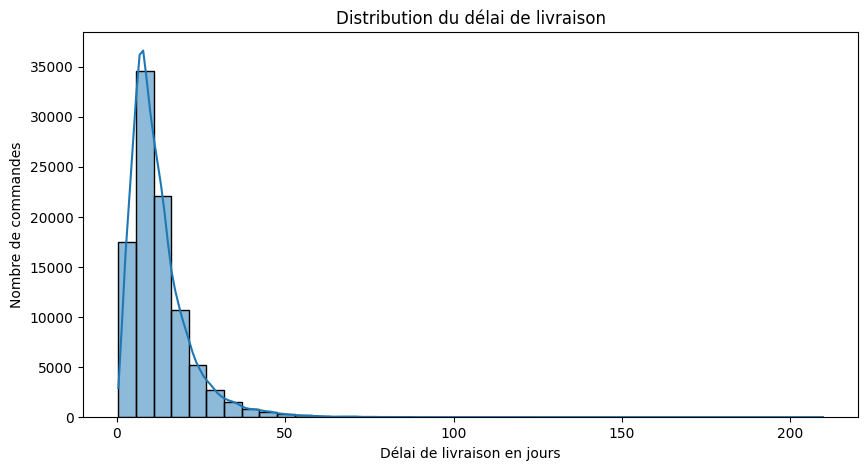

In [93]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivery,
    x="delivery_days",
    bins=40,
    kde=True
)

plt.title("Distribution du délai de livraison")
plt.xlabel("Délai de livraison en jours")
plt.ylabel("Nombre de commandes")

plt.show()

Graphique un peu ecrasé par le delais trop loing 

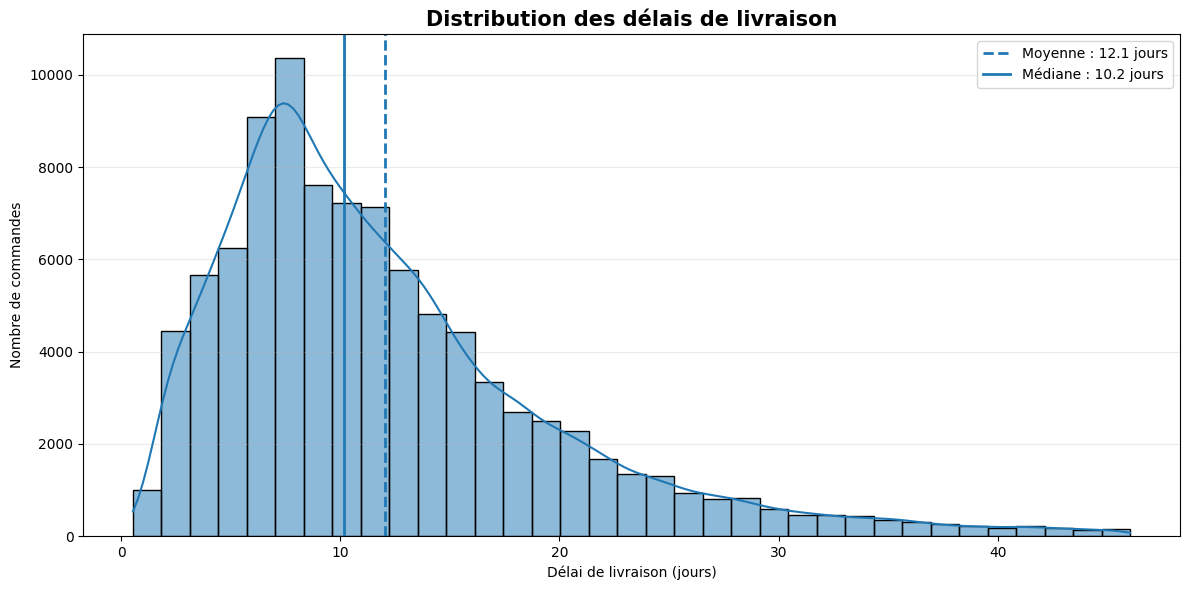

99e percentile : 46.1 jours
Moyenne : 12.1 jours
Médiane : 10.2 jours


In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garder uniquement les délais positifs
delivery_clean = delivery[
    delivery["delivery_days"] >= 0
].copy()

# 99e percentile pour éviter que quelques valeurs extrêmes
# écrasent tout le graphique
q99 = delivery_clean["delivery_days"].quantile(0.99)

delivery_zoom = delivery_clean[
    delivery_clean["delivery_days"] <= q99
]

# Statistiques
mean_delivery = delivery_zoom["delivery_days"].mean()
median_delivery = delivery_zoom["delivery_days"].median()

# Graphique
plt.figure(figsize=(12, 6))

sns.histplot(
    data=delivery_zoom,
    x="delivery_days",
    bins=35,
    kde=True
)

# Moyenne
plt.axvline(
    mean_delivery,
    linestyle="--",
    linewidth=2,
    label=f"Moyenne : {mean_delivery:.1f} jours"
)

# Médiane
plt.axvline(
    median_delivery,
    linestyle="-",
    linewidth=2,
    label=f"Médiane : {median_delivery:.1f} jours"
)

plt.title(
    "Distribution des délais de livraison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Délai de livraison (jours)")
plt.ylabel("Nombre de commandes")

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("99e percentile :", round(q99, 1), "jours")
print("Moyenne :", round(mean_delivery, 1), "jours")
print("Médiane :", round(median_delivery, 1), "jours")

La distribution des délais de livraison est asymétrique à droite. La majorité des commandes sont livrées dans un délai relativement court, tandis qu'un nombre limité de commandes présente des délais beaucoup plus élevés. Pour améliorer la lisibilité, le graphique est centré sur 99 % des observations. La comparaison entre la moyenne et la médiane permet également de mettre en évidence l'influence des délais extrêmes.

#### Graphique Livraison et satisfaction

In [95]:
# Creation d'une variable lisible 
df["delivery_status"] = np.where(
    df["is_late"],
    "En retard",
    "À l'heure / en avance"
)

In [97]:
review_delivery = (
    df
    .dropna(subset=["review_score", "delivery_status"])
    .groupby("delivery_status")["review_score"]
    .mean()
    .reset_index()
)

review_delivery

,delivery_status,review_score
0,En retard,2.566562
1,À l'heure / en avance,4.214778


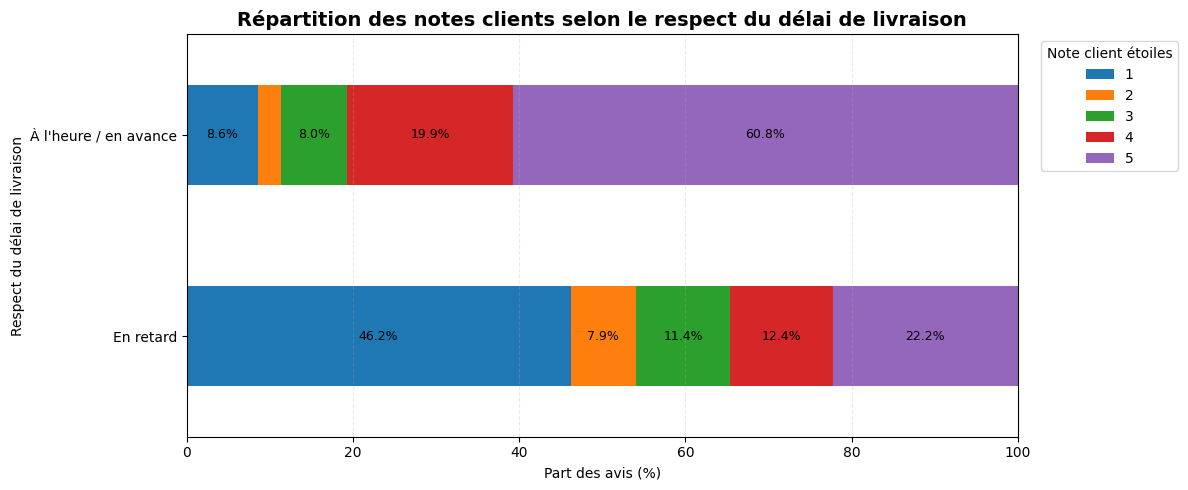

In [100]:
# Préparation des données


review_distribution = (
    df
    .dropna(subset=["delivery_status", "review_score"])
    .groupby(["delivery_status", "review_score"])
    .size()
    .unstack(fill_value=0)
)

# S'assurer que les notes sont dans l'ordre 1 à 5
review_distribution = review_distribution.reindex(
    columns=[1, 2, 3, 4, 5],
    fill_value=0
)

# Ordre logique des catégories
ordre = ["En retard", "À l'heure / en avance"]

review_distribution = review_distribution.reindex(
    [x for x in ordre if x in review_distribution.index]
)

# Transformation en pourcentage
review_percent = (
    review_distribution
    .div(review_distribution.sum(axis=1), axis=0)
    * 100
)


# Graphique


ax = review_percent.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 5)
)


# Ajouter les pourcentages dans les barres


for container in ax.containers:
    
    labels = [
        f"{value:.1f}%" if value >= 4 else ""
        for value in container.datavalues
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )


#  Mise en forme


plt.title(
    "Répartition des notes clients selon le respect du délai de livraison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Part des avis (%)")
plt.ylabel("Respect du délai de livraison")

plt.xlim(0, 100)

plt.legend(
    title="Note client étoiles",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

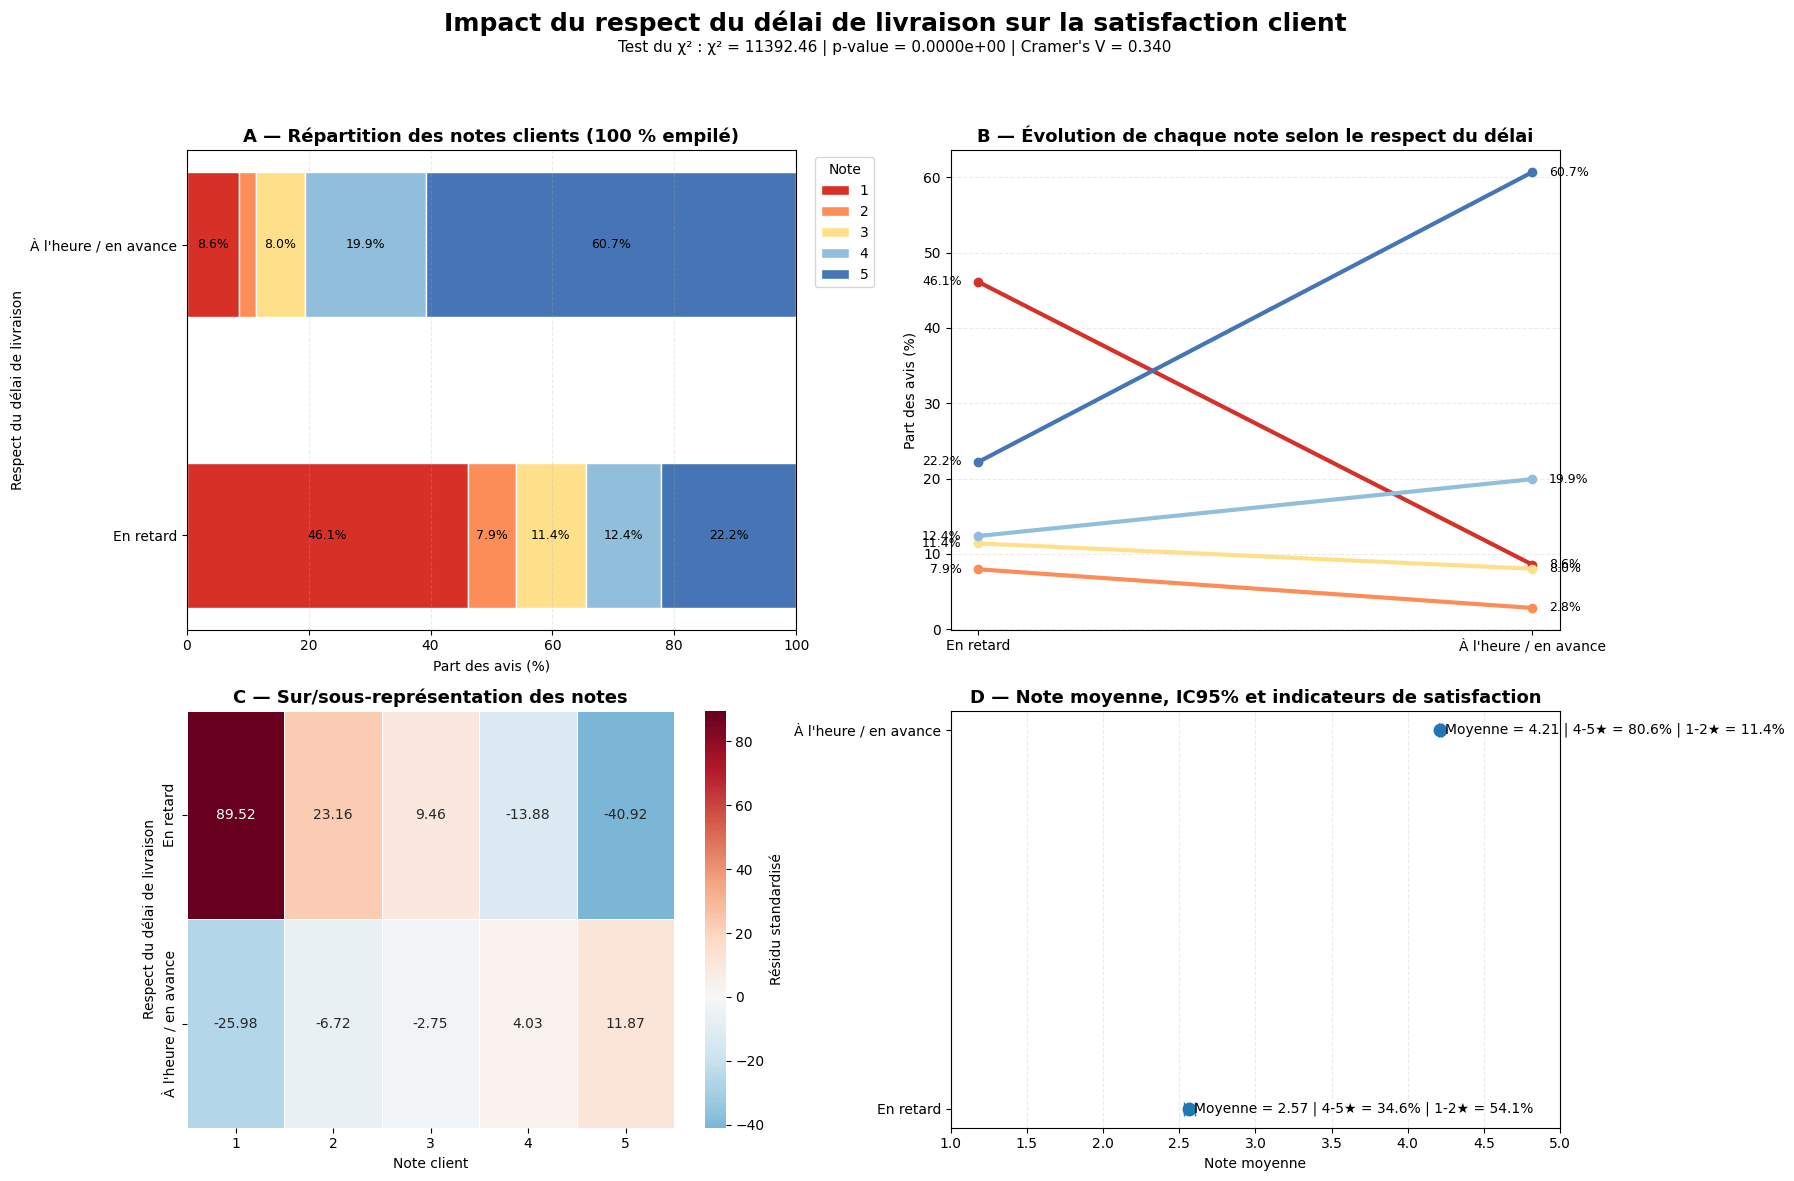

===== Tableau des effectifs =====


review_score,1,2,3,4,5
delivery_status,,,,,
En retard,3534,608,872,947,1701
À l'heure / en avance,7790,2551,7290,18126,55254



===== Tableau des pourcentages (%) =====


review_score,1,2,3,4,5
delivery_status,,,,,
En retard,46.12,7.94,11.38,12.36,22.20
À l'heure / en avance,8.56,2.80,8.01,19.92,60.71



===== Résidus standardisés =====


review_score,1,2,3,4,5
delivery_status,,,,,
En retard,89.52,23.16,9.46,-13.88,-40.92
À l'heure / en avance,-25.98,-6.72,-2.75,4.03,11.87



===== Résumé statistique =====


,mean,std,count,sem,ci95
delivery_status,,,,,
En retard,2.566,1.658,7662,0.019,0.037
À l'heure / en avance,4.214,1.234,91011,0.004,0.008



Chi2       : 11392.457
p-value    : 0.000000e+00
Cramer's V : 0.340


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from matplotlib.gridspec import GridSpec

# ==========================================================
# 1. PREPARATION DES DONNEES
# ==========================================================

review_data = (
    df[["delivery_status", "review_score"]]
    .dropna()
    .copy()
)

# S'assurer que review_score est entier
review_data["review_score"] = review_data["review_score"].astype(int)

# Ordre logique
delivery_order = ["En retard", "À l'heure / en avance"]
score_order = [1, 2, 3, 4, 5]

# Tableau de contingence
counts = pd.crosstab(
    review_data["delivery_status"],
    review_data["review_score"]
).reindex(index=delivery_order, columns=score_order, fill_value=0)

# Pourcentages par ligne
percent = counts.div(counts.sum(axis=1), axis=0) * 100

# ==========================================================
# 2. STATISTIQUES
# ==========================================================

# Test du chi2
chi2, p_value, dof, expected = chi2_contingency(counts)

# Taille d'effet : Cramer's V
n = counts.to_numpy().sum()
r, k = counts.shape
cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

# Résidus standardisés
residuals = (counts - expected) / np.sqrt(expected)

# Stats moyennes + IC95%
summary_stats = (
    review_data.groupby("delivery_status")["review_score"]
    .agg(["mean", "std", "count"])
    .reindex(delivery_order)
)

summary_stats["sem"] = summary_stats["std"] / np.sqrt(summary_stats["count"])
summary_stats["ci95"] = 1.96 * summary_stats["sem"]

# Taux de satisfaction / insatisfaction
kpi = pd.DataFrame(index=delivery_order)
kpi["part_1_2"] = percent[[1, 2]].sum(axis=1)
kpi["part_4_5"] = percent[[4, 5]].sum(axis=1)
kpi["part_5"] = percent[5]
kpi["part_1"] = percent[1]
kpi["note_moyenne"] = summary_stats["mean"]

# ==========================================================
# 3. FIGURE GLOBALE
# ==========================================================

plt.figure(figsize=(18, 12))
gs = GridSpec(2, 2, figure=plt.gcf(), height_ratios=[1.15, 1])

# Palette
palette_scores = {
    1: "#d73027",
    2: "#fc8d59",
    3: "#fee08b",
    4: "#91bfdb",
    5: "#4575b4"
}

# ==========================================================
# A. BARRES EMPILEES 100%
# ==========================================================

ax1 = plt.subplot(gs[0, 0])

left = np.zeros(len(percent))

for score in score_order:
    values = percent[score].values
    ax1.barh(
        percent.index,
        values,
        left=left,
        label=str(score),
        color=palette_scores[score],
        edgecolor="white",
        height=0.5
    )

    # Affichage des labels si la part est assez grande
    for i, v in enumerate(values):
        if v >= 4:
            ax1.text(
                left[i] + v / 2,
                i,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )
    left += values

ax1.set_xlim(0, 100)
ax1.set_xlabel("Part des avis (%)")
ax1.set_ylabel("Respect du délai de livraison")
ax1.set_title("A — Répartition des notes clients (100 % empilé)", fontsize=13, fontweight="bold")
ax1.legend(title="Note", bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.grid(axis="x", linestyle="--", alpha=0.25)

# ==========================================================
# B. SLOPE CHART DES NOTES
# ==========================================================

ax2 = plt.subplot(gs[0, 1])

x_positions = [0, 1]

for score in score_order:
    y_values = [
        percent.loc["En retard", score],
        percent.loc["À l'heure / en avance", score]
    ]
    
    ax2.plot(
        x_positions,
        y_values,
        marker="o",
        linewidth=3,
        label=f"Note {score}",
        color=palette_scores[score]
    )
    
    ax2.text(-0.03, y_values[0], f"{y_values[0]:.1f}%", ha="right", va="center", fontsize=9)
    ax2.text(1.03, y_values[1], f"{y_values[1]:.1f}%", ha="left", va="center", fontsize=9)

ax2.set_xticks(x_positions)
ax2.set_xticklabels(["En retard", "À l'heure / en avance"])
ax2.set_ylabel("Part des avis (%)")
ax2.set_title("B — Évolution de chaque note selon le respect du délai", fontsize=13, fontweight="bold")
ax2.grid(axis="y", linestyle="--", alpha=0.25)

# ==========================================================
# C. HEATMAP DES RESIDUS STANDARDISES
# ==========================================================

ax3 = plt.subplot(gs[1, 0])

sns.heatmap(
    residuals,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Résidu standardisé"},
    ax=ax3
)

ax3.set_title("C — Sur/sous-représentation des notes", fontsize=13, fontweight="bold")
ax3.set_xlabel("Note client")
ax3.set_ylabel("Respect du délai de livraison")

# ==========================================================
# D. MOYENNE + IC95 + KPI SATISFACTION
# ==========================================================

ax4 = plt.subplot(gs[1, 1])

y_pos = np.arange(len(delivery_order))
means = summary_stats["mean"].values
ci = summary_stats["ci95"].values

ax4.errorbar(
    means,
    y_pos,
    xerr=ci,
    fmt="o",
    capsize=5,
    markersize=9,
    linewidth=2
)

for i, status in enumerate(delivery_order):
    ax4.text(
        means[i] + 0.03,
        y_pos[i],
        f"Moyenne = {means[i]:.2f} | 4-5★ = {kpi.loc[status, 'part_4_5']:.1f}% | 1-2★ = {kpi.loc[status, 'part_1_2']:.1f}%",
        va="center",
        fontsize=10
    )

ax4.set_yticks(y_pos)
ax4.set_yticklabels(delivery_order)
ax4.set_xlim(1, 5)
ax4.set_xlabel("Note moyenne")
ax4.set_title("D — Note moyenne, IC95% et indicateurs de satisfaction", fontsize=13, fontweight="bold")
ax4.grid(axis="x", linestyle="--", alpha=0.25)

# ==========================================================
# TITRE GENERAL + SOUS-TITRE STATISTIQUE
# ==========================================================

plt.suptitle(
    "Impact du respect du délai de livraison sur la satisfaction client",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.figtext(
    0.5,
    0.945,
    f"Test du χ² : χ² = {chi2:.2f} | p-value = {p_value:.4e} | Cramer's V = {cramers_v:.3f}",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ==========================================================
# 4. AFFICHAGE DES KPI COMPLEMENTAIRES
# ==========================================================

print("===== Tableau des effectifs =====")
display(counts)

print("\n===== Tableau des pourcentages (%) =====")
display(percent.round(2))

print("\n===== Résidus standardisés =====")
display(residuals.round(2))

print("\n===== Résumé statistique =====")
display(summary_stats.round(3))

print(f"\nChi2       : {chi2:.3f}")
print(f"p-value    : {p_value:.6e}")
print(f"Cramer's V : {cramers_v:.3f}")

In [130]:
# Variables intéressantes pour l'analyse de corrélation
variables_corr = [
    "payment_value",
    "products_value",
    "freight_value",
    "items_count",
    "unique_products",
    "unique_sellers",
    "payment_transactions",
    "max_installments",
    "delivery_days",
    "delay_days",
    "review_score"
]

# On ne conserve que les colonnes réellement présentes dans df
variables_corr = [
    col for col in variables_corr
    if col in df.columns
]

corr_data = df[variables_corr].copy()

print("Variables utilisées :")
print(variables_corr)

corr_data.head()

Variables utilisées :
['payment_value', 'products_value', 'freight_value', 'items_count', 'unique_products', 'unique_sellers', 'payment_transactions', 'max_installments', 'delivery_days', 'delay_days', 'review_score']


,payment_value,products_value,freight_value,items_count,unique_products,unique_sellers,payment_transactions,max_installments,delivery_days,delay_days,review_score
0,38.71,29.99,8.72,1.0,1.0,1.0,3.0,1.0,8.436574,-7.107488,4.0
1,141.46,118.70,22.76,1.0,1.0,1.0,1.0,1.0,13.782037,-5.355729,4.0
2,179.12,159.90,19.22,1.0,1.0,1.0,1.0,3.0,9.394213,-17.245498,5.0
3,72.20,45.00,27.20,1.0,1.0,1.0,1.0,1.0,13.208750,-12.980069,5.0
4,28.62,19.90,8.72,1.0,1.0,1.0,1.0,1.0,2.873877,-9.238171,5.0


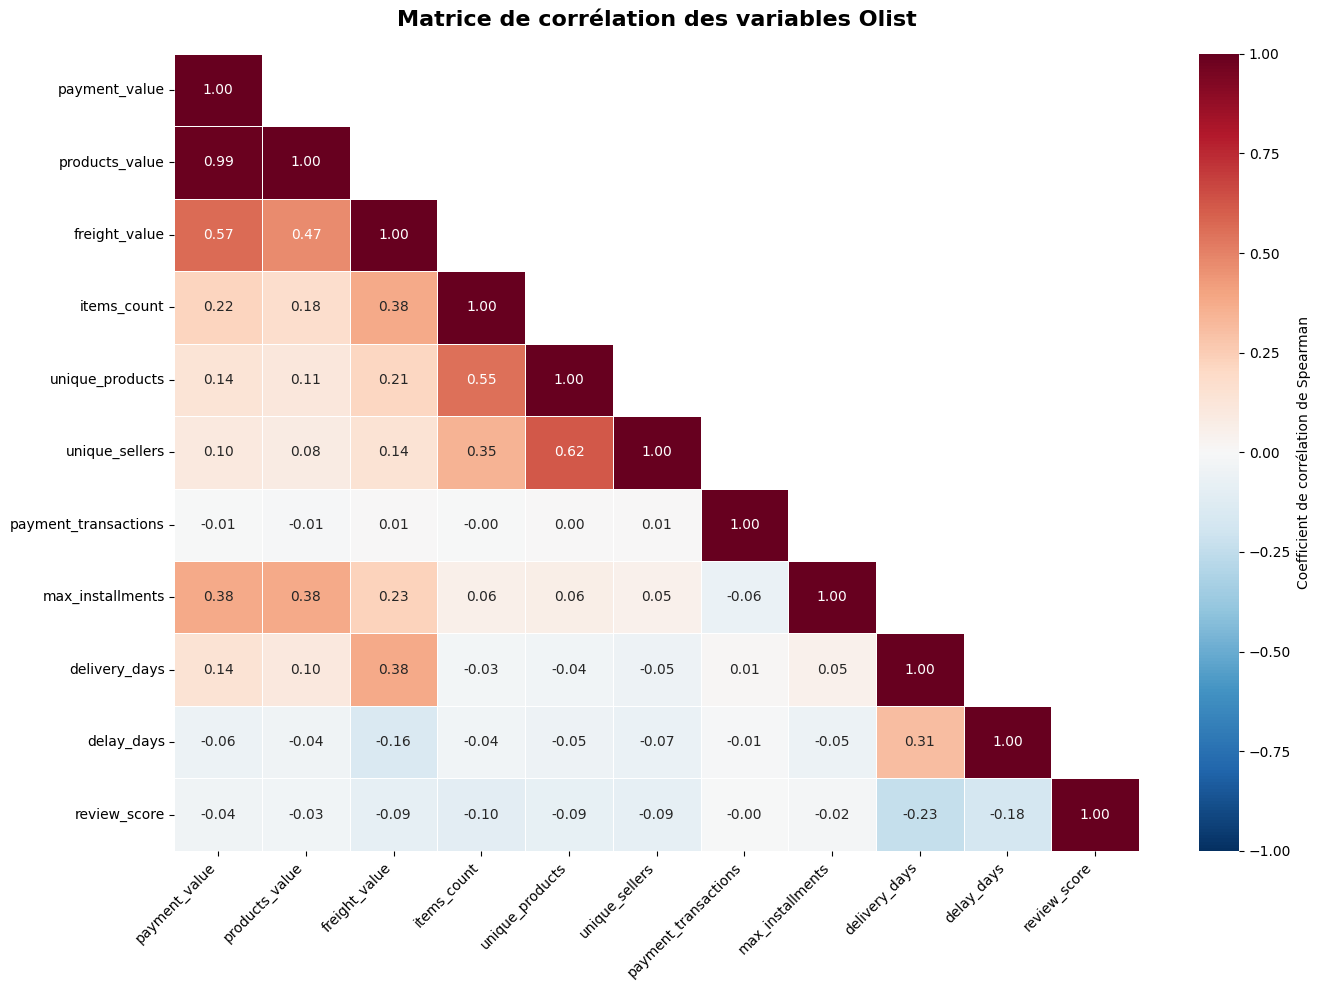

In [131]:
# Corrélation de Spearman
corr_matrix = corr_data.corr(method="spearman")

# Masque pour n'afficher qu'une moitié de la matrice
mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool),
    k=1
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Coefficient de corrélation de Spearman"
    }
)

plt.title(
    "Matrice de corrélation des variables Olist",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [132]:
# Récupérer uniquement les couples de variables
upper_triangle = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

upper_triangle.columns = [
    "Variable_1",
    "Variable_2",
    "Correlation"
]

# Valeur absolue pour classer la force de la relation
upper_triangle["Force_absolue"] = (
    upper_triangle["Correlation"].abs()
)

# Classement
top_correlations = (
    upper_triangle
    .sort_values("Force_absolue", ascending=False)
    .reset_index(drop=True)
)

top_correlations.head(15)

,Variable_1,Variable_2,Correlation,Force_absolue
0,payment_value,products_value,0.989721,0.989721
1,unique_products,unique_sellers,0.622313,0.622313
2,payment_value,freight_value,0.566379,0.566379
3,items_count,unique_products,0.553302,0.553302
4,products_value,freight_value,0.469040,0.469040
5,payment_value,max_installments,0.381681,0.381681
6,freight_value,delivery_days,0.381459,0.381459
7,freight_value,items_count,0.376946,0.376946
8,products_value,max_installments,0.375325,0.375325
9,items_count,unique_sellers,0.345019,0.345019


In [133]:
def niveau_correlation(r):
    
    r_abs = abs(r)

    if r_abs < 0.20:
        return "Très faible"

    elif r_abs < 0.40:
        return "Faible"

    elif r_abs < 0.60:
        return "Modérée"

    elif r_abs < 0.80:
        return "Forte"

    else:
        return "Très forte"

In [134]:
top_correlations["Intensite"] = (
    top_correlations["Correlation"]
    .apply(niveau_correlation)
)

top_correlations.head(15)

,Variable_1,Variable_2,Correlation,Force_absolue,Intensite
0,payment_value,products_value,0.989721,0.989721,Très forte
1,unique_products,unique_sellers,0.622313,0.622313,Forte
2,payment_value,freight_value,0.566379,0.566379,Modérée
3,items_count,unique_products,0.553302,0.553302,Modérée
4,products_value,freight_value,0.469040,0.469040,Modérée
5,payment_value,max_installments,0.381681,0.381681,Faible
6,freight_value,delivery_days,0.381459,0.381459,Faible
7,freight_value,items_count,0.376946,0.376946,Faible
8,products_value,max_installments,0.375325,0.375325,Faible
9,items_count,unique_sellers,0.345019,0.345019,Faible


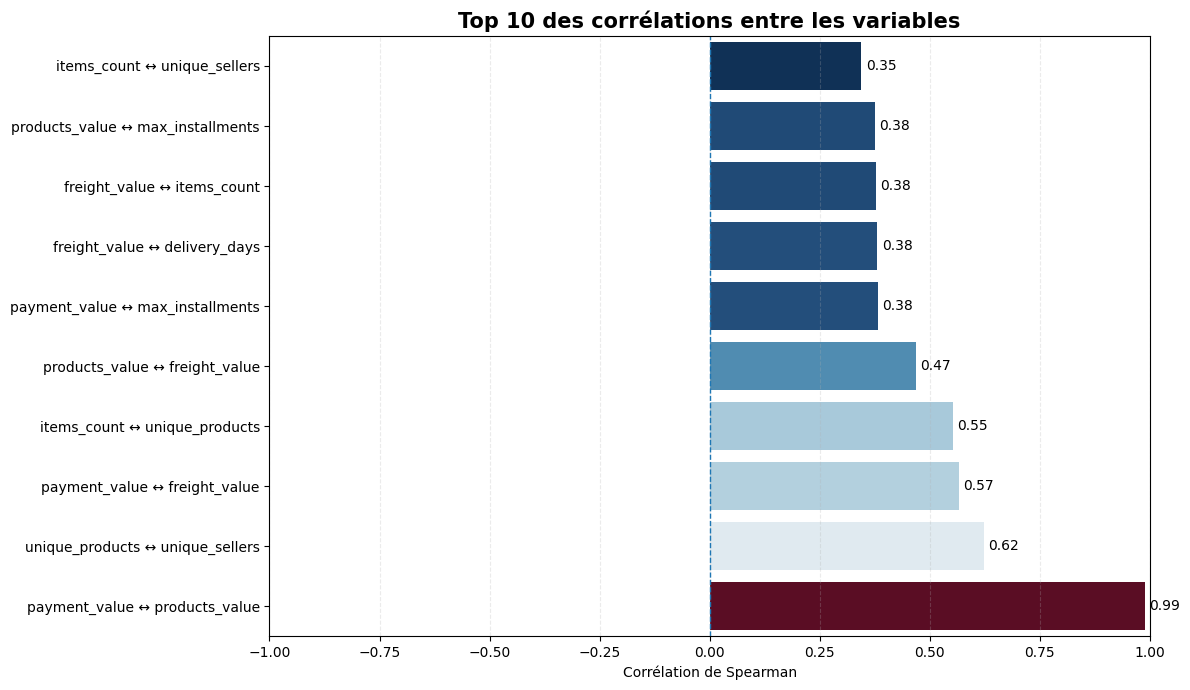

In [135]:
top10 = top_correlations.head(10).copy()

top10["Relation"] = (
    top10["Variable_1"]
    + " ↔ "
    + top10["Variable_2"]
)

# Trier pour le graphique horizontal
top10 = top10.sort_values("Correlation")

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top10,
    x="Correlation",
    y="Relation",
    hue="Correlation",
    palette="RdBu_r",
    legend=False
)

# Ligne zéro
plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

# Afficher la valeur
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title(
    "Top 10 des corrélations entre les variables",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Corrélation de Spearman")
plt.ylabel("")

plt.xlim(-1, 1)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [136]:
delivery_review = df[
    ["delay_days", "review_score"]
].dropna()

In [137]:
spearman_delay_review = (
    delivery_review["delay_days"]
    .corr(
        delivery_review["review_score"],
        method="spearman"
    )
)

print(
    "Corrélation retard / note :",
    round(spearman_delay_review, 3)
)

Corrélation retard / note : -0.176


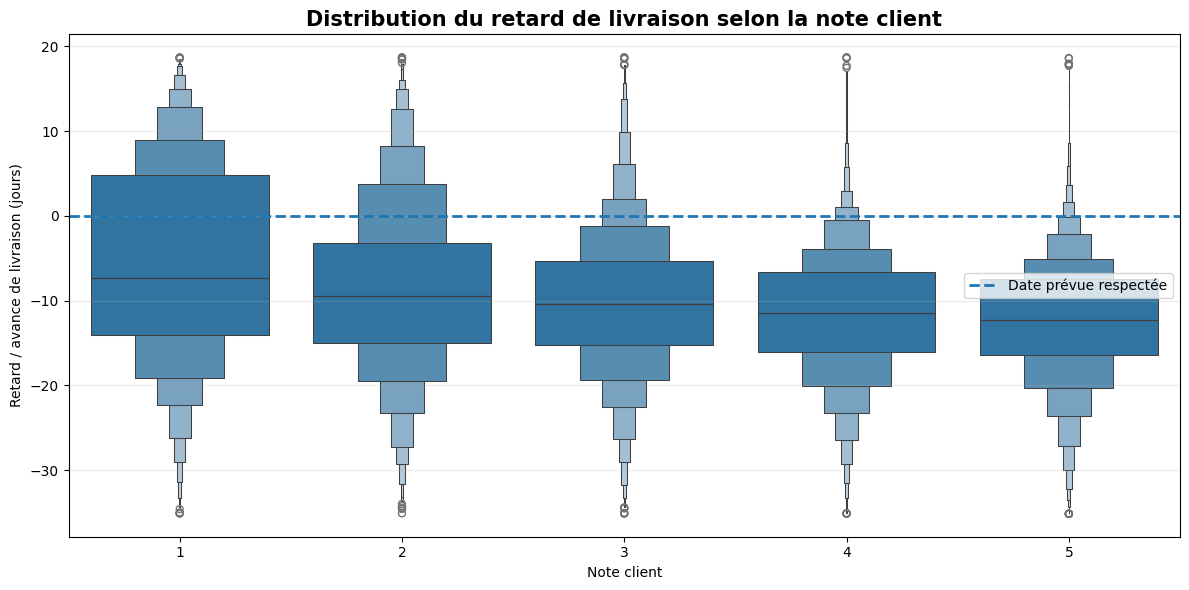

In [ ]:

# Préparation des données

viz = df[["delay_days", "review_score"]].dropna().copy()

# Transformer la note en catégories entières 1 à 5
viz["review_score_cat"] = viz["review_score"].round().clip(1, 5).astype(int)

# Limiter l'affichage pour éviter que les extrêmes écrasent le graphe
low = viz["delay_days"].quantile(0.01)
high = viz["delay_days"].quantile(0.99)

viz_plot = viz[
    viz["delay_days"].between(low, high)
].copy()


# Graphique

plt.figure(figsize=(12, 6))

sns.boxenplot(
    data=viz_plot,
    x="review_score_cat",
    y="delay_days"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    label="Date prévue respectée"
)

plt.title(
    "Distribution du retard de livraison selon la note client",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Note client")
plt.ylabel("Retard / avance de livraison (jours)")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [139]:
delay_by_review = (
    df
    .dropna(subset=["review_score", "delay_days"])
    .groupby("review_score")
    .agg(
        retard_moyen=("delay_days", "mean"),
        retard_median=("delay_days", "median"),
        nb_commandes=("order_id", "nunique")
    )
    .reset_index()
)

delay_by_review

,review_score,retard_moyen,retard_median,nb_commandes
0,1.000000,-3.336156,-6.370579,9316
1,1.500000,-5.342746,-8.819931,8
2,2.000000,-7.938540,-9.306140,2916
3,2.500000,-6.819354,-10.250347,30
4,3.000000,-10.084415,-10.363744,7916
5,3.333333,-13.091065,-13.091065,1
6,3.500000,-13.220016,-12.164664,23
7,4.000000,-11.682696,-11.494086,18868
8,4.333333,-10.287153,-10.287153,1
9,4.500000,-12.358327,-12.423530,53


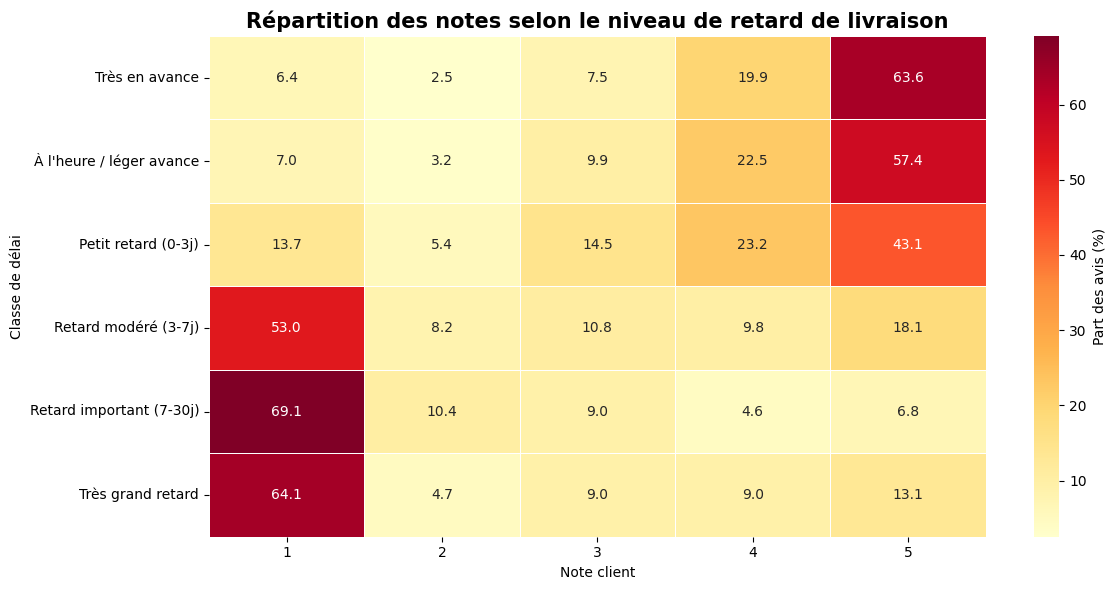

In [146]:
# =========================
# 1. Préparation des données
# =========================
viz = df[["delay_days", "review_score"]].dropna().copy()
viz["review_score_cat"] = viz["review_score"].round().clip(1, 5).astype(int)

# Créer des classes de retard / avance
viz["delay_class"] = pd.cut(
    viz["delay_days"],
    bins=[-100, -7, 0, 3, 7, 30, 300],
    labels=[
        "Très en avance",
        "À l'heure / léger avance",
        "Petit retard (0-3j)",
        "Retard modéré (3-7j)",
        "Retard important (7-30j)",
        "Très grand retard"
    ]
)

# Tableau croisé en pourcentage ligne
heat = pd.crosstab(
    viz["delay_class"],
    viz["review_score_cat"],
    normalize="index"
) * 100

# Réordonner si besoin
heat = heat[[1, 2, 3, 4, 5]]

# =========================
# 2. Heatmap
# =========================
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Part des avis (%)"}
)

plt.title(
    "Répartition des notes selon le niveau de retard de livraison",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Note client")
plt.ylabel("Classe de délai")
plt.tight_layout()
plt.show()

In [142]:
pearson_corr = corr_data.corr(
    method="pearson"
)

spearman_corr = corr_data.corr(
    method="spearman"
)

In [143]:
variable_x = "delay_days"
variable_y = "review_score"

print(
    "Pearson :",
    round(
        pearson_corr.loc[
            variable_x,
            variable_y
        ],
        3
    )
)

print(
    "Spearman :",
    round(
        spearman_corr.loc[
            variable_x,
            variable_y
        ],
        3
    )
)

Pearson : -0.267
Spearman : -0.176


In [ ]:
# INDICATEURS COMMERCIAUX PAR ÉTAT
state_metrics = (
    df
    .groupby("customer_state")
    .agg(
        nb_commandes=("order_id", "nunique"),
        nb_clients=("customer_unique_id", "nunique"),
        montant_total=("payment_value", "sum"),
        panier_moyen=("payment_value", "mean"),
        note_moyenne=("review_score", "mean")
    )
    .reset_index()
)

state_metrics.head()

,customer_state,nb_commandes,nb_clients,montant_total,panier_moyen,note_moyenne
0,AC,81,77,19680.62,242.970617,4.049383
1,AL,413,401,96962.06,234.774964,3.760976
2,AM,148,143,27966.93,188.965743,4.205479
3,AP,68,67,16262.80,239.158824,4.194030
4,BA,3380,3277,616645.82,182.439592,3.861078


In [120]:
delivery_state = (
    df[
        (df["order_status"] == "delivered") &
        (df["delivery_days"].notna()) &
        (df["delay_days"].notna())
    ]
    .groupby("customer_state")
    .agg(
        delai_moyen=("delivery_days", "mean"),
        taux_retard=("delay_days", lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
)

delivery_state.head()

,customer_state,delai_moyen,taux_retard
0,AC,21.035713,3.750000
1,AL,24.543855,23.929471
2,AM,26.425991,4.137931
3,AP,27.185068,4.477612
4,BA,19.335466,14.035627


In [121]:
state_metrics = state_metrics.merge(
    delivery_state,
    on="customer_state",
    how="left"
)

In [122]:
state_metrics["part_commandes"] = (
    state_metrics["nb_commandes"]
    / state_metrics["nb_commandes"].sum()
    * 100
)

In [123]:
state_metrics["part_commandes"] = (
    state_metrics["nb_commandes"]
    / state_metrics["nb_commandes"].sum()
    * 100
)

In [124]:
state_metrics.sort_values(
    "nb_commandes",
    ascending=False
).head(10)

,customer_state,nb_commandes,nb_clients,montant_total,panier_moyen,note_moyenne,delai_moyen,taux_retard,part_commandes
25,SP,41746,40302,5998226.96,143.687315,4.174126,8.761386,5.894700,41.980672
18,RJ,12852,12384,2144379.69,166.851828,3.877263,15.309438,13.473684,12.924247
10,MG,11635,11259,1872257.26,160.915966,4.135754,12.008666,5.610358,11.700405
22,RS,5466,5277,890898.54,162.989122,4.133658,15.300276,7.148204,5.496727
17,PR,5045,4882,811156.38,160.784218,4.181112,11.991582,4.996953,5.073360
23,SC,3637,3534,623086.43,171.318787,4.073705,14.954783,9.757473,3.657445
4,BA,3380,3277,616645.82,182.439592,3.861078,19.335466,14.035627,3.399000
6,DF,2140,2075,355141.08,165.953776,4.066964,12.967568,7.067308,2.152030
7,ES,2033,1964,325967.55,160.338195,4.038385,15.789307,12.230576,2.044428
8,GO,2020,1952,350092.31,173.313025,4.043348,15.606339,8.175779,2.031355


In [125]:
map_advanced = brazil_states.merge(
    state_metrics,
    left_on="UF",
    right_on="customer_state",
    how="left"
)

In [126]:
map_advanced[
    [
        "UF",
        "nb_commandes",
        "montant_total",
        "panier_moyen",
        "note_moyenne",
        "taux_retard"
    ]
].head()

,UF,nb_commandes,montant_total,panier_moyen,note_moyenne,taux_retard
0,AC,81,19680.62,242.970617,4.049383,3.750000
1,AL,413,96962.06,234.774964,3.760976,23.929471
2,AM,148,27966.93,188.965743,4.205479,4.137931
3,AP,68,16262.80,239.158824,4.194030,4.477612
4,BA,3380,616645.82,182.439592,3.861078,14.035627


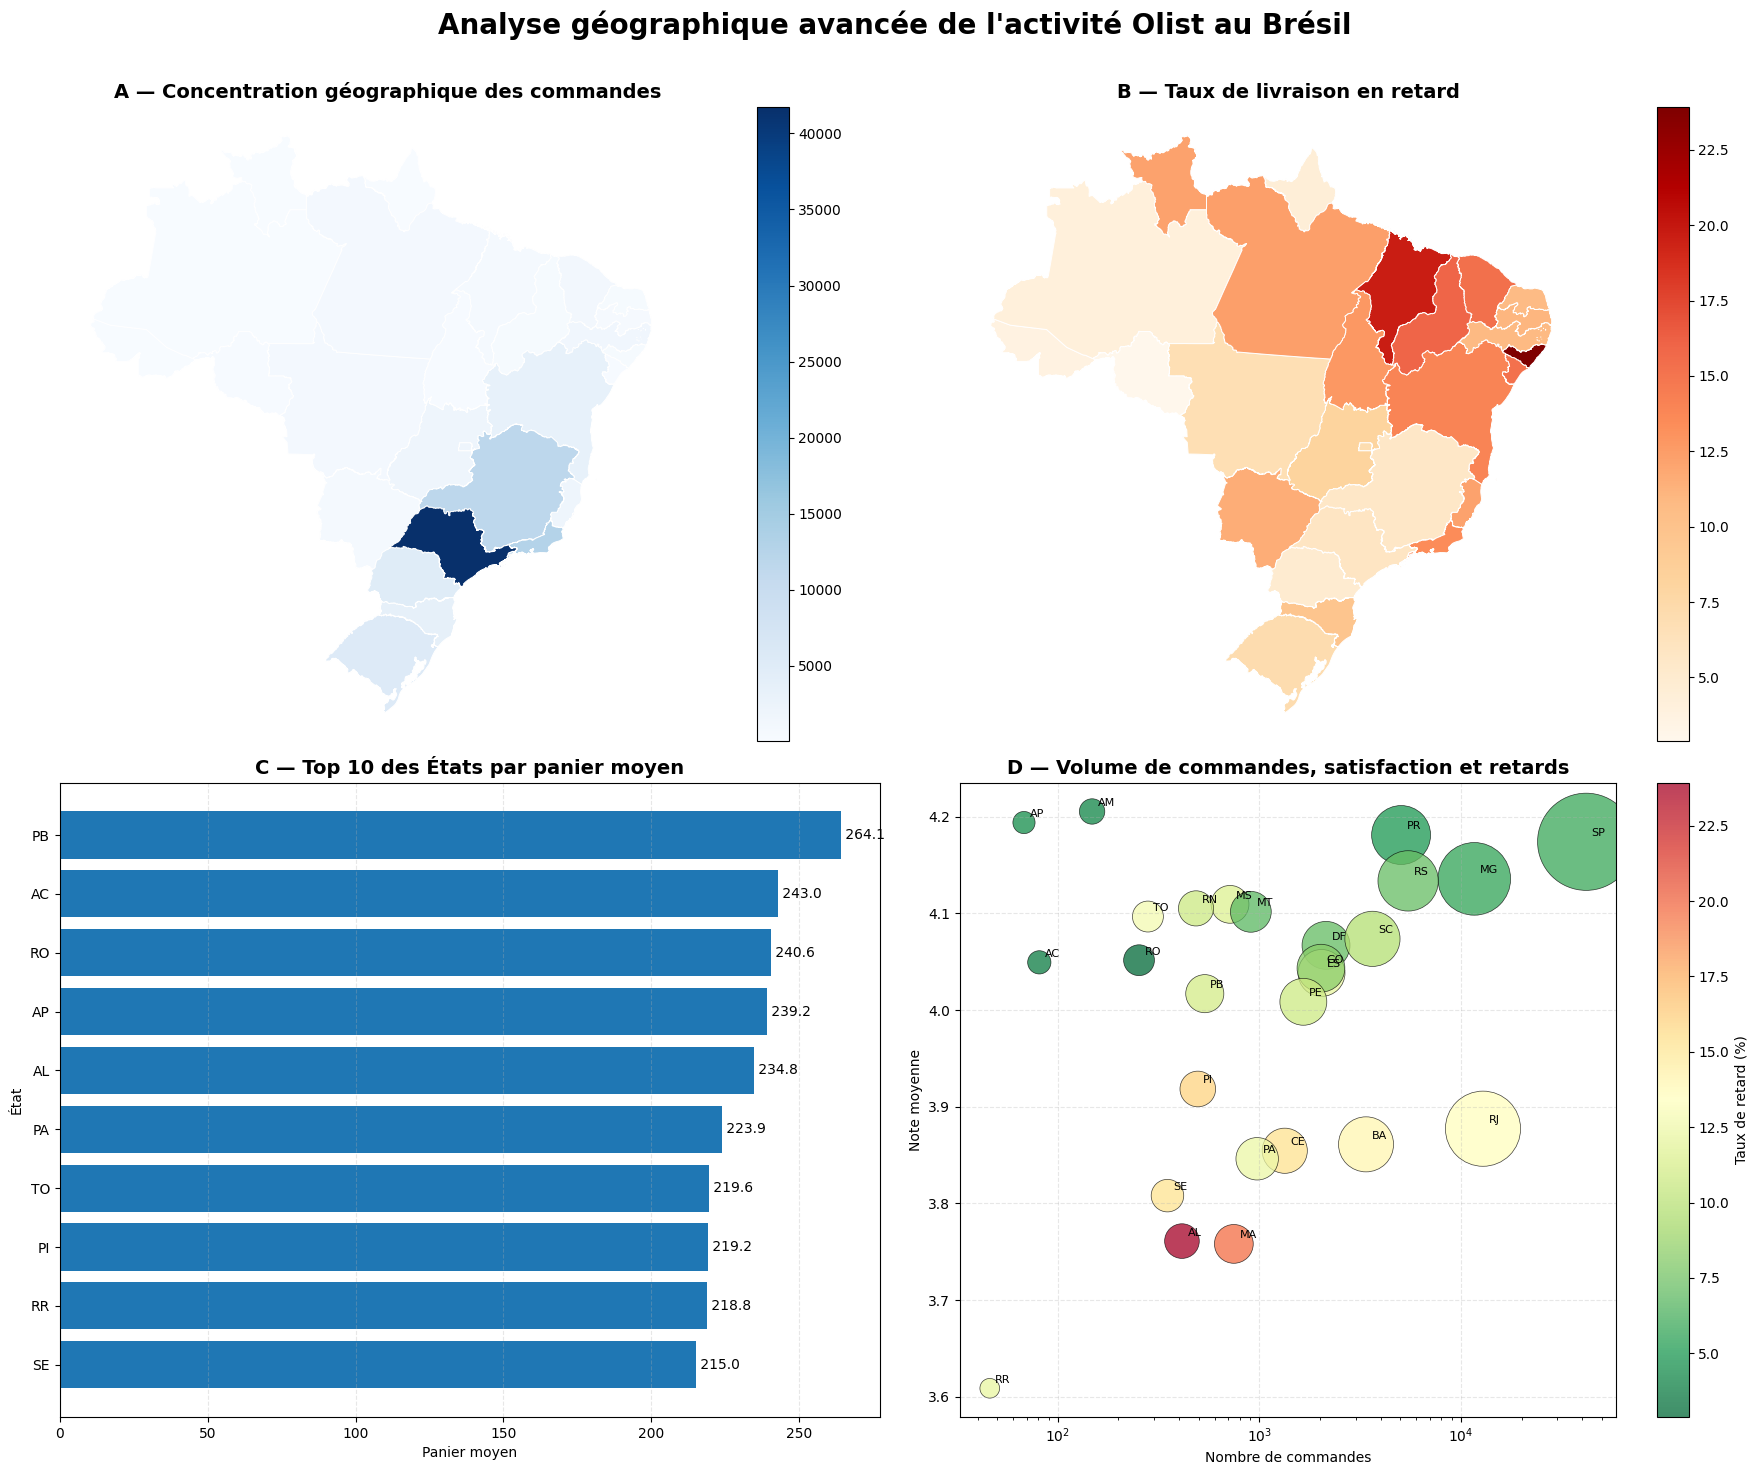

In [ ]:

# DASHBOARD GÉOGRAPHIQUE AVANCÉ OLIST
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 15)
)


# CARTE 1 - NOMBRE DE COMMANDES
map_advanced.plot(
    column="nb_commandes",
    cmap="Blues",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    ax=axes[0, 0],
    missing_kwds={
        "color": "lightgrey",
        "label": "Pas de données"
    }
)

axes[0, 0].set_title(
    "A — Concentration géographique des commandes",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].axis("off")



# CARTE 2 - TAUX DE RETARD
map_advanced.plot(
    column="taux_retard",
    cmap="OrRd",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    ax=axes[0, 1],
    missing_kwds={
        "color": "lightgrey",
        "label": "Pas de données"
    }
)

axes[0, 1].set_title(
    "B — Taux de livraison en retard",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].axis("off")


# GRAPHIQUE 3 - TOP 10 PANIER MOYEN

top_panier = (
    state_metrics
    .sort_values("panier_moyen", ascending=False)
    .head(10)
    .sort_values("panier_moyen")
)

axes[1, 0].barh(
    top_panier["customer_state"],
    top_panier["panier_moyen"]
)

axes[1, 0].set_title(
    "C — Top 10 des États par panier moyen",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Panier moyen")
axes[1, 0].set_ylabel("État")

axes[1, 0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Valeurs sur les barres
for i, value in enumerate(top_panier["panier_moyen"]):
    axes[1, 0].text(
        value,
        i,
        f" {value:.1f}",
        va="center"
    )


# GRAPHIQUE 4 - VOLUME VS SATISFACTION

scatter = axes[1, 1].scatter(
    state_metrics["nb_commandes"],
    state_metrics["note_moyenne"],
    s=np.sqrt(state_metrics["montant_total"]) * 2,
    c=state_metrics["taux_retard"],
    cmap="RdYlGn_r",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5
)

# Ajouter les codes des États
for _, row in state_metrics.iterrows():

    axes[1, 1].annotate(
        row["customer_state"],
        (
            row["nb_commandes"],
            row["note_moyenne"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

axes[1, 1].set_title(
    "D — Volume de commandes, satisfaction et retards",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Nombre de commandes")
axes[1, 1].set_ylabel("Note moyenne")

axes[1, 1].grid(
    linestyle="--",
    alpha=0.3
)

# Échelle logarithmique car SP est très dominant
axes[1, 1].set_xscale("log")

# Barre de couleur
cbar = fig.colorbar(
    scatter,
    ax=axes[1, 1]
)

cbar.set_label("Taux de retard (%)")


# TITRE GÉNÉRAL

fig.suptitle(
    "Analyse géographique avancée de l'activité Olist au Brésil",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

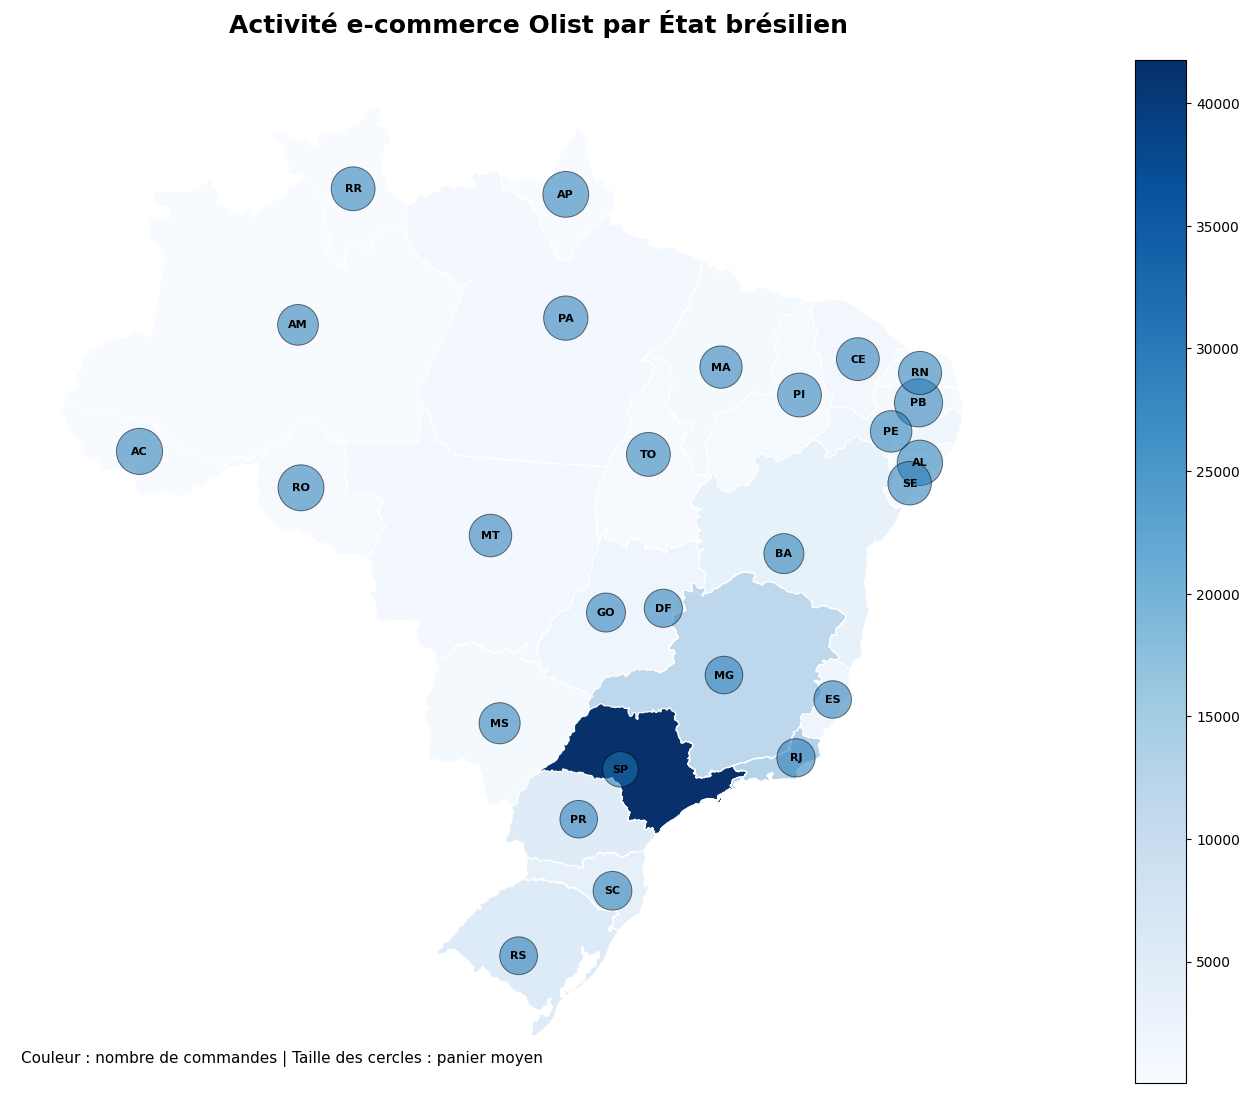

In [ ]:


fig, ax = plt.subplots(figsize=(14, 11))

# Fond : nombre de commandes
map_advanced.plot(
    column="nb_commandes",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)


# Calcul de points représentatifs


projected = map_advanced.to_crs(epsg=31983)

points = projected.representative_point()

points = gpd.GeoSeries(
    points,
    crs=projected.crs
).to_crs(map_advanced.crs)


# Bulles : panier moyen


bubble_sizes = (
    map_advanced["panier_moyen"]
    / map_advanced["panier_moyen"].max()
    * 1200
)

ax.scatter(
    points.x,
    points.y,
    s=bubble_sizes,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.7
)

# Codes des États


for i, row in map_advanced.iterrows():

    if pd.notna(row["UF"]):

        ax.annotate(
            row["UF"],
            (
                points.iloc[i].x,
                points.iloc[i].y
            ),
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

ax.set_title(
    "Activité e-commerce Olist par État brésilien",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.text(
    0.01,
    0.02,
    "Couleur : nombre de commandes | Taille des cercles : panier moyen",
    transform=ax.transAxes,
    fontsize=11
)

ax.axis("off")

plt.tight_layout()
plt.show()

#### Analyse sur le poids du transport

In [148]:
items_products["total_item_cost"] = (
    items_products["price"]
    + items_products["freight_value"]
)

items_products["freight_ratio"] = (
    items_products["freight_value"]
    / items_products["total_item_cost"]
    * 100
)

In [149]:
items_products["freight_ratio"].describe()

count    112650.000000
mean         21.336434
std          12.949813
min           0.000000
25%          11.819196
50%          18.788733
75%          28.214357
max          96.328294
Name: freight_ratio, dtype: float64

In [150]:
geo_zip = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    .agg(
        latitude=("geolocation_lat", "mean"),
        longitude=("geolocation_lng", "mean")
    )
    .reset_index()
)

In [151]:
customers_geo = customers.merge(
    geo_zip,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
    validate="many_to_one"
)

In [152]:
print("Avant :", len(orders))
print("Après :", len(df))

Avant : 99441
Après : 99441


In [153]:
df["order_id"].nunique()

99441

In [154]:
numeric_columns = [
    "payment_value",
    "products_value",
    "freight_value",
    "items_count",
    "delivery_days",
    "delay_days",
    "review_score"
]

corr = df[numeric_columns].corr()

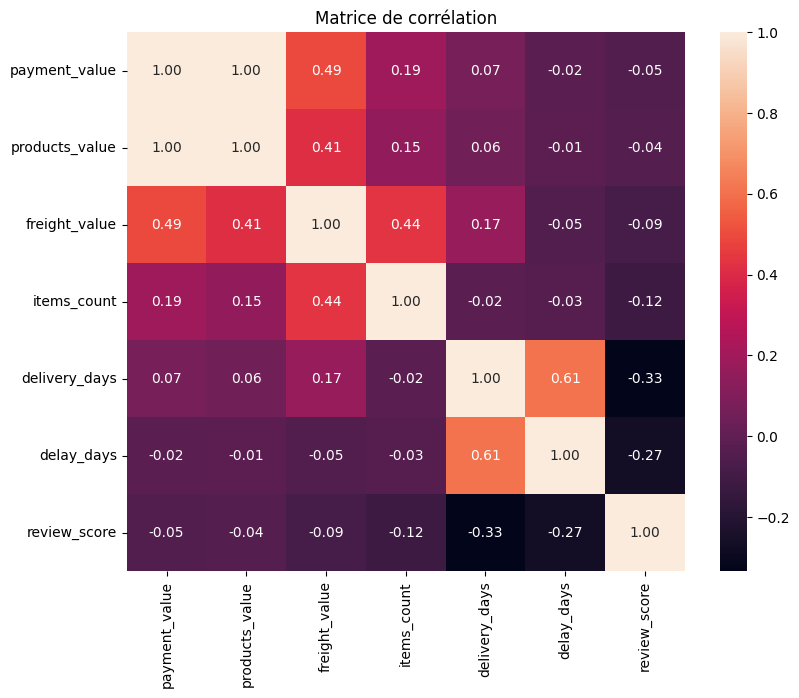

In [156]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()